In [1]:
import os
import random
import time
from datetime import date
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#DATA_PATH = "./data/2025-07-15_full_training_data_98066_samples.csv" # carbons log-uniform, others uniform
DATA_PATH = "./data/2025-07-22_full_training_data_29446_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_19637_samples.csv" # carbons log-uniform, others uniform
#DATA_PATH = "./data/2025-07-22_full_training_data_9844_samples.csv" # carbons log-uniform, others uniform
#datafile = "./data/2025-07-15_full_training_data_99518_easy_samples.csv" #log-uniform samples

In [3]:
# Set all random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

In [4]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

print(f"PyTorch version: {torch.__version__}")

Training on device: cuda
PyTorch version: 2.5.1+cu121


In [5]:
def print_gpu_memory():
    """
    Displays the current GPU memory usage by PyTorch on the active CUDA device.
    Useful for monitoring GPU memory usage during training.
    """
    if torch.cuda.is_available():
        device = torch.cuda.current_device()
        allocated = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f'Allocated memory: {allocated:.2f} MB')
        print(f'Reserved memory: {reserved:.2f} MB')
    else:
        print("CUDA is not available.")

In [6]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=8, n_heads=2, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )
        # c projection to match d_model
        self.Wc_proj = nn.Linear(1, d_model, bias=False)
        self.Wc_out = nn.Linear(d_model, 1, bias=False)

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x)
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True)
        # attn_out: (B, S, d_model)
        # attn_weights: (B, S, S) averaged over heads

        x_out = attn_out + x
        c_proj = self.Wc_proj(c)            # (B, S, d_model)
        # Apply attention weights: (B, S, S) @ (B, S, d_model) -> (B, S, d_model)
        c_att = torch.bmm(attn_weights, c_proj)
        c_out = self.Wc_out(c_att) + c      # (B, S, 1)

        return x_out, c_out

In [7]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.LeakyReLU(0.01)
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        #hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [8]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=8, n_heads=2, d_ff=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c

In [9]:
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size=115,
        d_model=8,
        n_heads=2,
        n_layers=2,
        d_ff=128,
        dropout=0.1
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        
        self.input_embedding = nn.Embedding(vocab_size, d_model)
        
        self.layers = nn.ModuleList([
            FluxTransformerLayer(
                d_model=d_model,
                n_heads=n_heads,
                d_ff=d_ff,
                dropout=dropout
            )
            for _ in range(n_layers)
        ])

    def forward(self, c):
        batch_size = c.size(0)
        
        # Create token indices once
        y = torch.arange(self.vocab_size, device=c.device)
        y = y.unsqueeze(0).expand(batch_size, -1)  # (batch, seq)
        
        # Embed tokens once
        x = self.input_embedding(y)  # (batch, seq, d_model)
        
        for layer in self.layers:
            x, c = layer(x, c)
        
        return c

In [10]:
def load_data(filepath):
    """Load and preprocess the training data"""
    inputs = [
        'EX_glc__D_e', 'EX_fru_e', 'EX_lac__D_e', 'EX_pyr_e', 'EX_ac_e',
        'EX_akg_e', 'EX_succ_e', 'EX_fum_e', 'EX_mal__L_e', 'EX_etoh_e',
        'EX_acald_e', 'EX_for_e', 'EX_gln__L_e', 'EX_glu__L_e',
        'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_nh4_e', 'EX_o2_e', 'EX_pi_e'
    ]

    outputs = [
        'ACALD_flux', 'ACALDt_flux', 'ACKr_flux', 'ACONTa_flux', 'ACONTb_flux',
        'ACt2r_flux', 'ADK1_flux', 'AKGDH_flux', 'AKGt2r_flux', 'ALCD2x_flux',
        'ATPM_flux', 'ATPS4r_flux', 'Biomass_Ecoli_core_flux', 'CO2t_flux', 'CS_flux',
        'CYTBD_flux', 'D_LACt2_flux', 'ENO_flux', 'ETOHt2r_flux', 'EX_ac_e_flux',
        'EX_acald_e_flux', 'EX_akg_e_flux', 'EX_co2_e_flux', 'EX_etoh_e_flux', 'EX_for_e_flux',
        'EX_fru_e_flux', 'EX_fum_e_flux', 'EX_glc__D_e_flux', 'EX_gln__L_e_flux', 'EX_glu__L_e_flux',
        'EX_h_e_flux', 'EX_h2o_e_flux', 'EX_lac__D_e_flux', 'EX_mal__L_e_flux', 'EX_nh4_e_flux',
        'EX_o2_e_flux', 'EX_pi_e_flux', 'EX_pyr_e_flux', 'EX_succ_e_flux', 'FBA_flux',
        'FBP_flux', 'FORt2_flux', 'FORti_flux', 'FRD7_flux', 'FRUpts2_flux',
        'FUM_flux', 'FUMt2_2_flux', 'G6PDH2r_flux', 'GAPD_flux', 'GLCpts_flux',
        'GLNS_flux', 'GLNabc_flux', 'GLUDy_flux', 'GLUN_flux', 'GLUSy_flux',
        'GLUt2r_flux', 'GND_flux', 'H2Ot_flux', 'ICDHyr_flux', 'ICL_flux',
        'LDH_D_flux', 'MALS_flux', 'MALt2_2_flux', 'MDH_flux', 'ME1_flux',
        'ME2_flux', 'NADH16_flux', 'NADTRHD_flux', 'NH4t_flux', 'O2t_flux',
        'PDH_flux', 'PFK_flux', 'PFL_flux', 'PGI_flux', 'PGK_flux',
        'PGL_flux', 'PGM_flux', 'PIt2r_flux', 'PPC_flux', 'PPCK_flux',
        'PPS_flux', 'PTAr_flux', 'PYK_flux', 'PYRt2_flux', 'RPE_flux',
        'RPI_flux', 'SUCCt2_2_flux', 'SUCCt3_flux', 'SUCDi_flux', 'SUCOAS_flux',
        'TALA_flux', 'THD2_flux', 'TKT1_flux', 'TKT2_flux', 'TPI_flux'
    ]
    all_columns = inputs + outputs
    
    df = pd.read_csv(filepath)

    # Fill missing inputs with 0 (i.e., not uptaken)
    df[inputs] = df[inputs].fillna(0)

    print(f"\nLoaded data with {len(df)} samples from {filepath}")
    print(f"Number of input features: {len(inputs)}")
    print(f"Number of output targets: {len(outputs)}")

    X = df[inputs].to_numpy(dtype=np.float32)
    y = df[outputs].to_numpy(dtype=np.float32)

    X_combined = np.hstack([X, np.zeros_like(y)])
    y_combined = np.hstack([np.zeros_like(X), y])

    return X_combined, y_combined, all_columns

In [11]:
def prepare_tensors(X, y, test_size=0.4, device="cpu"):
    """
    Split data into train/test and convert to PyTorch tensors.
    
    Parameters:
        X (ndarray): Input features.
        y (ndarray): Output targets.
        test_size (float): Fraction of data to reserve for testing.
        device (str or torch.device): Device to move tensors to.
    
    Returns:
        X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor (torch.Tensor)
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")

    # Optional: standardize inputs (only input features, i.e., first 20 columns)
    # scaler = StandardScaler()
    # X_train[:, :20] = scaler.fit_transform(X_train[:, :20])
    # X_test[:, :20] = scaler.transform(X_test[:, :20])

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    return X_train_tensor, X_test_tensor, y_train_tensor, y_test_tensor

In [12]:
# Load and preprocess data

X, y, columns = load_data(DATA_PATH)
X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)


Loaded data with 29446 samples from ./data/2025-07-22_full_training_data_29446_samples.csv
Number of input features: 20
Number of output targets: 95
Training samples: 17667
Test samples: 11779


In [13]:
X_train.size(), y_train.size(), len(columns)

(torch.Size([17667, 115]), torch.Size([17667, 115]), 115)

In [14]:
def train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128, 
               batch_size=128, num_epochs=1000, learning_rate=0.001):
    start_time = time.time()
    # Create datasets with correct dimensions
    train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
    test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = FluxTransformer(
        vocab_size=115,
        d_model=d_model,
        n_heads=n_heads,
        n_layers=n_layers,
        d_ff=d_ff
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    #criterion = nn.MSELoss()
    criterion = nn.HuberLoss()

    train_losses = []
    test_losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0)

            # Explicitly free tensors
            del predictions, loss
            torch.cuda.empty_cache()
        
        epoch_train_loss /= len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Evaluation
        model.eval()
        epoch_test_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)
                epoch_test_loss += loss.item() * batch_X.size(0)

                # Explicitly free tensors
                del predictions, loss
                torch.cuda.empty_cache()
        
        epoch_test_loss /= len(test_loader.dataset)
        test_losses.append(epoch_test_loss)

        if (epoch+1) % 100 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {epoch_train_loss:.6f} | "
                f"Test Loss: {epoch_test_loss:.6f}")
        
        # Additional memory cleanup after epoch
        torch.cuda.empty_cache()
        gc.collect()

    print('Training Completed.')
    end_time = time.time()
    elapsed_time = end_time - start_time
    mins, secs = divmod(elapsed_time, 60)
    print(f"Training took {int(mins)} min {secs:.1f} sec.")
    
    return train_losses, test_losses, model

In [15]:
def plot_loss_curves(train_losses, test_losses, d_model, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Training and Test Loss for d_model = {d_model}", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    plt.show()

In [16]:
def plot_diagnostics_2x2(y_true, y_pred, label):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples"""
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))
    
    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    axs[0, 0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    plt.show()
    plt.close()

In [17]:
def plot_prediction_sample(X_test, y_test, model):
    X_test_ = X_test.unsqueeze(-1)
    y_test_ = y_test.unsqueeze(-1)
    j = np.random.randint(0, X_test_.size(0), 1)[0]
    pred = model(X_test_[j].unsqueeze(0))
    true = y_test_[j].unsqueeze(0)
    plt.plot(pred[0,:,0].cpu().detach().numpy(), label='Predicted')
    plt.plot(true[0,:,0].cpu().detach().numpy(), label='True')

    # add a red vertical line at index 32 (biomass)
    plt.axvline(x=32, color='red', linestyle='--', linewidth=1)
    
    plt.legend()
    plt.title(f"Sample index {j}")
    plt.xlabel("Reaction ID")
    plt.ylabel("Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [18]:
def plot_flux(
    model,
    X_test,
    y_test,
    columns,
    flux_name: str,
    device: torch.device,
):
    """ Displays a 2x2 diagnostic plot for the chosen flux."""
    output_cols = columns[20:]
    X_test_ = X_test.unsqueeze(-1)

    model.eval()
    with torch.no_grad():
        y_pred_tensor = model(X_test_.to(device))  # shape: [n_samples, 115, 1]
    print("y_pred_tensor.shape:", y_pred_tensor.shape)

    y_pred_full = y_pred_tensor.squeeze(-1).cpu().numpy()  # shape: [n_samples, 115]
    print("y_pred_full.shape:", y_pred_full.shape,
            "min/max:", y_pred_full.min(), y_pred_full.max())

    y_true_full = y_test.cpu().numpy()                     # shape: [n_samples, 115]
    print("y_true_full.shape:", y_true_full.shape,
            "min/max:", y_true_full.min(), y_true_full.max())

    # Extract only the output predictions (last 95 columns)
    y_pred_outputs = y_pred_full[:, 20:]
    y_true_outputs = y_true_full[:, 20:]
    print("y_pred_outputs.shape:", y_pred_outputs.shape,
            "min/max:", y_pred_outputs.min(), y_pred_outputs.max())
    print("y_true_outputs.shape:", y_true_outputs.shape,
            "min/max:", y_true_outputs.min(), y_true_outputs.max())

    try:
        idx = output_cols.index(flux_name)
    except ValueError:
        raise ValueError(f"Flux '{flux_name}' not found in output_cols")

    # Verify the correct column
    print(f"Flux column index in outputs: {idx}")
    print(f"y_true_outputs[:, idx] range:",
            y_true_outputs[:, idx].min(), "to", y_true_outputs[:, idx].max())
    print(f"y_pred_outputs[:, _idx] range:",
            y_pred_outputs[:, idx].min(), "to", y_pred_outputs[:, idx].max())

    # Plot diagnostics specifically for given flux
    plot_diagnostics_2x2(
        y_true=y_true_outputs[:, idx],
        y_pred=y_pred_outputs[:, idx],
        label=flux_name
    )

Allocated memory: 25.84 MB
Reserved memory: 40.00 MB
Epoch 100/1000 | Train Loss: 1.193739 | Test Loss: 1.207000
Epoch 200/1000 | Train Loss: 1.024290 | Test Loss: 1.023061
Epoch 300/1000 | Train Loss: 0.929510 | Test Loss: 1.048234
Epoch 400/1000 | Train Loss: 0.846347 | Test Loss: 0.873144
Epoch 500/1000 | Train Loss: 0.806621 | Test Loss: 0.856939
Epoch 600/1000 | Train Loss: 0.771859 | Test Loss: 0.890478
Epoch 700/1000 | Train Loss: 0.746670 | Test Loss: 0.801590
Epoch 800/1000 | Train Loss: 0.719976 | Test Loss: 0.722220
Epoch 900/1000 | Train Loss: 0.707270 | Test Loss: 0.714925
Epoch 1000/1000 | Train Loss: 0.696617 | Test Loss: 0.670225
Training Completed.
Training took 44 min 53.3 sec.


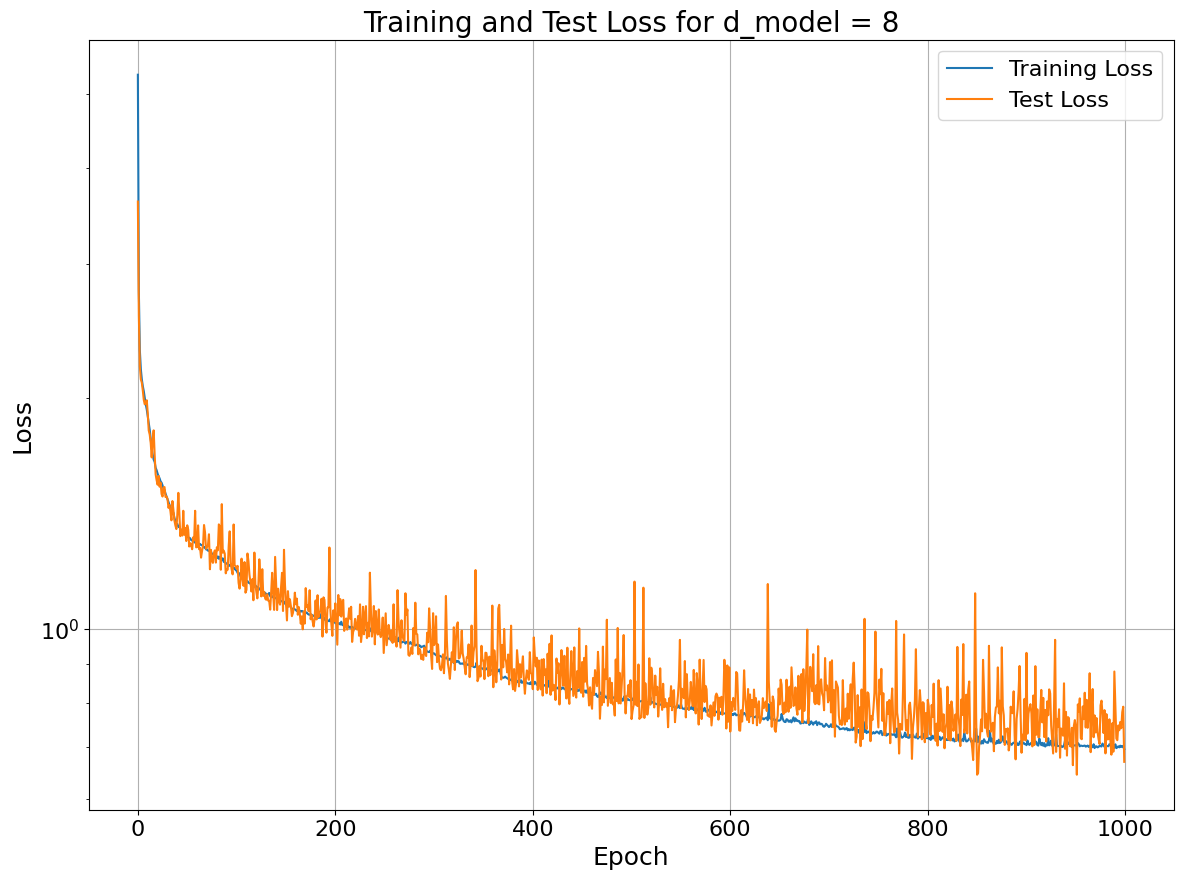

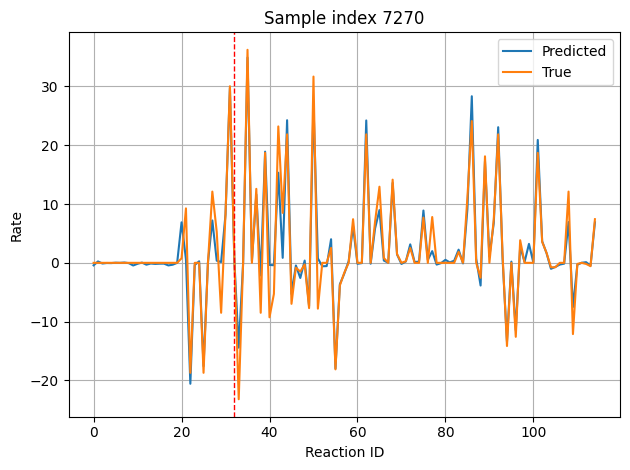

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -69.28035 103.45684
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -69.28035 103.45684
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.08238804 to 3.130858


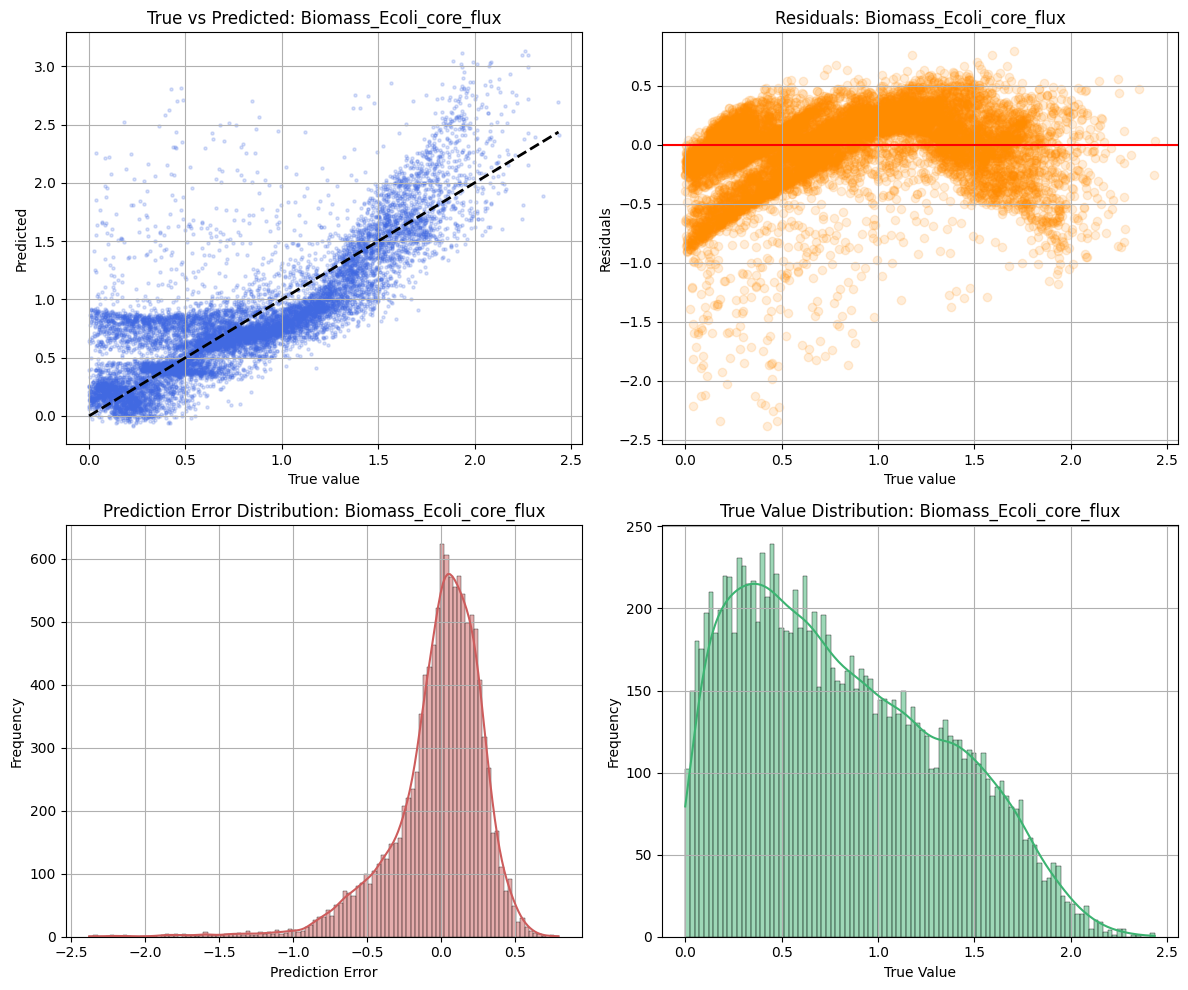

Number of parameters:
6478


In [20]:
print_gpu_memory()

train_losses, test_losses, model_822 = train_model(d_model=8, n_heads=2, n_layers=2, d_ff=128)

plot_loss_curves(train_losses, test_losses, d_model=8)

plot_prediction_sample(X_test, y_test, model_822)

plot_flux(model_822, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_822.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.768496 | Test Loss: 0.793778
Epoch 200/1000 | Train Loss: 0.638602 | Test Loss: 0.632510
Epoch 300/1000 | Train Loss: 0.588085 | Test Loss: 0.572333
Epoch 400/1000 | Train Loss: 0.558730 | Test Loss: 0.675669
Epoch 500/1000 | Train Loss: 0.524800 | Test Loss: 0.458982
Epoch 600/1000 | Train Loss: 0.514609 | Test Loss: 0.466456
Epoch 700/1000 | Train Loss: 0.495876 | Test Loss: 0.458131
Epoch 800/1000 | Train Loss: 0.485761 | Test Loss: 0.471911
Epoch 900/1000 | Train Loss: 0.476130 | Test Loss: 0.438401
Epoch 1000/1000 | Train Loss: 0.473204 | Test Loss: 0.422785
Training Completed.
Training took 48 min 19.3 sec.


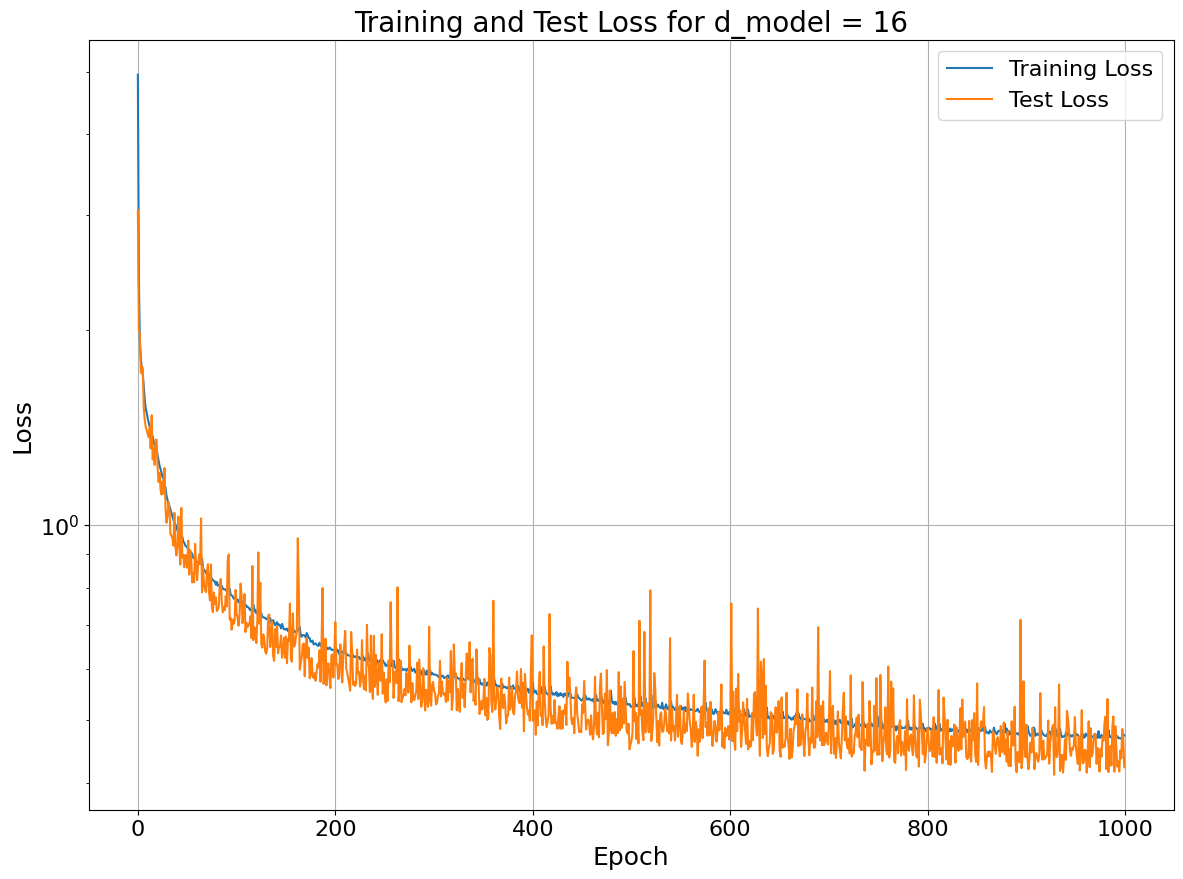

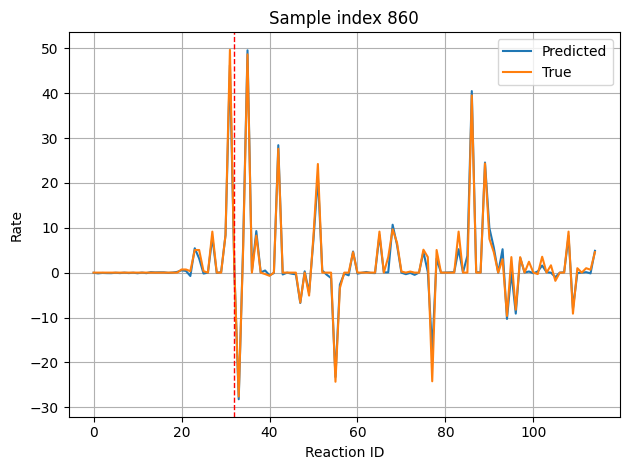

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -72.681816 106.20048
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -72.681816 106.20048
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.33522773 to 2.5168545


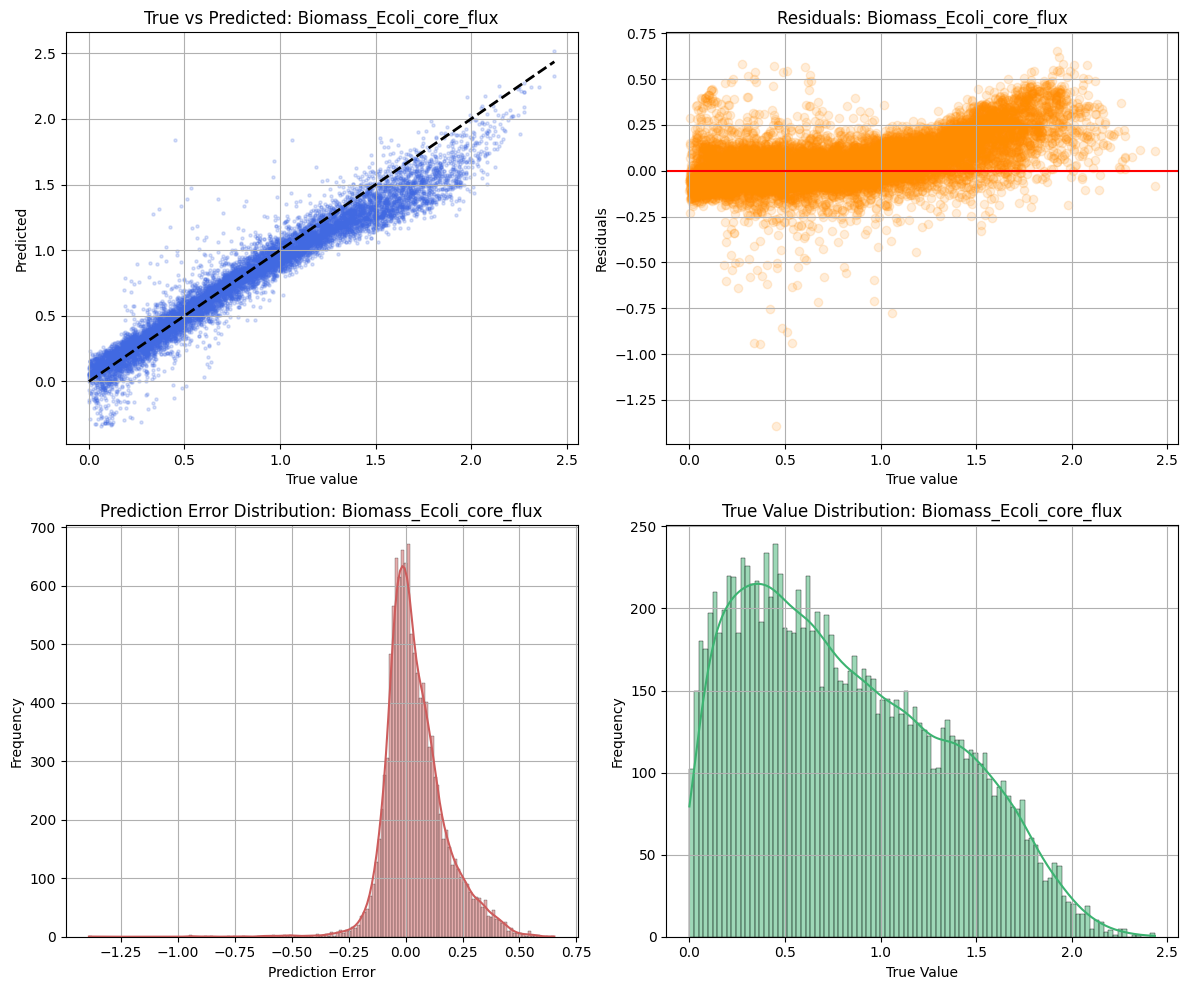

Number of parameters:
13206


In [21]:
train_losses_1622, test_losses_1622, model_1622 = train_model(d_model=16, n_heads=2, n_layers=2, d_ff=128)

plot_loss_curves(train_losses_1622, test_losses_1622, d_model=16)

plot_prediction_sample(X_test, y_test, model_1622)

plot_flux(model_1622, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_1622.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.765791 | Test Loss: 0.677515
Epoch 200/1000 | Train Loss: 0.611648 | Test Loss: 0.546678
Epoch 300/1000 | Train Loss: 0.564798 | Test Loss: 0.516874
Epoch 400/1000 | Train Loss: 0.535092 | Test Loss: 0.503184
Epoch 500/1000 | Train Loss: 0.518835 | Test Loss: 0.519950
Epoch 600/1000 | Train Loss: 0.519413 | Test Loss: 0.478617
Epoch 700/1000 | Train Loss: 0.497646 | Test Loss: 0.498558
Epoch 800/1000 | Train Loss: 0.486867 | Test Loss: 0.418689
Epoch 900/1000 | Train Loss: 0.477643 | Test Loss: 0.468817
Epoch 1000/1000 | Train Loss: 0.478536 | Test Loss: 0.411866
Training Completed.
Training took 61 min 47.6 sec.


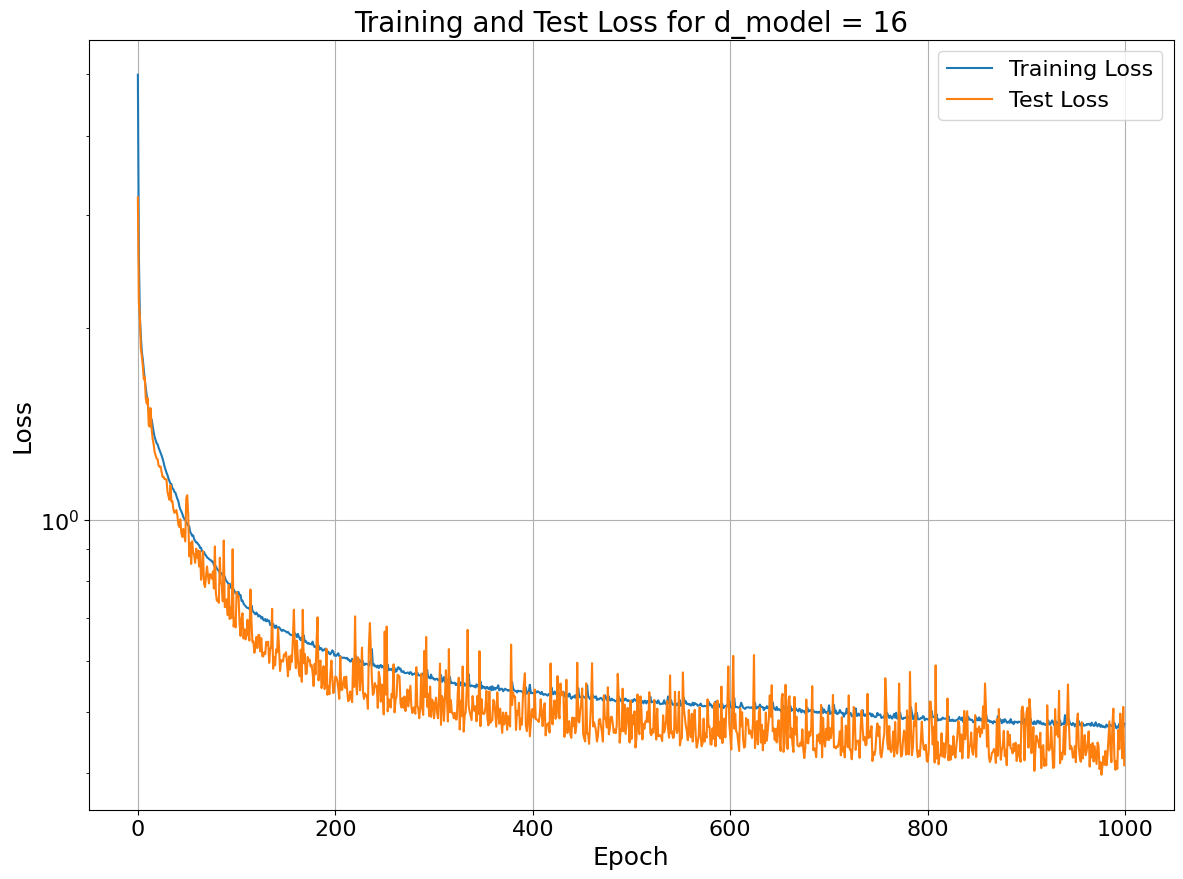

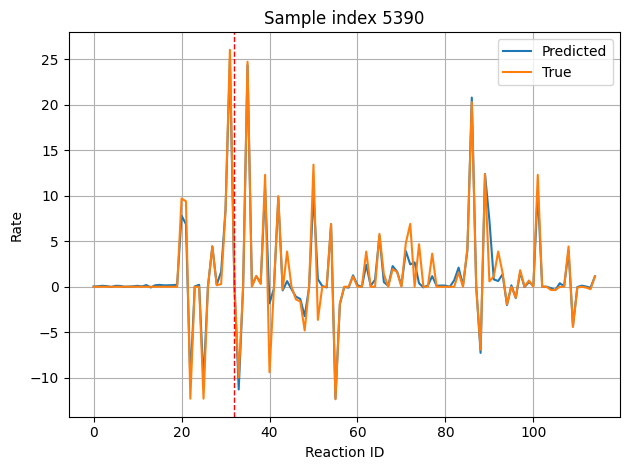

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -74.531456 107.351425
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -74.531456 107.351425
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.26706725 to 1.9689119


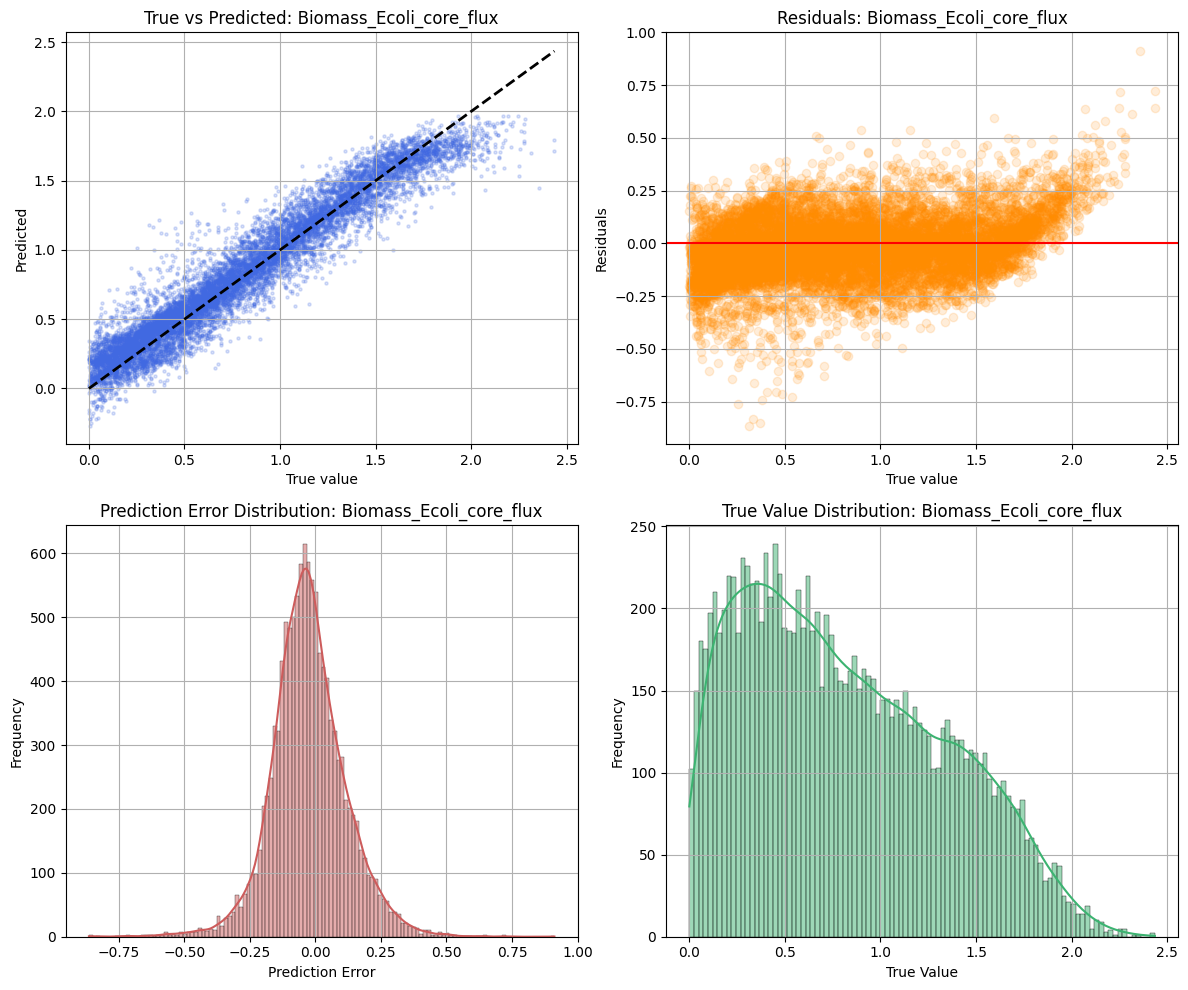

Number of parameters:
13206


In [22]:
train_losses_1642, test_losses_1642, model_1642 = train_model(d_model=16, n_heads=4, n_layers=2, d_ff=128)

plot_loss_curves(train_losses_1642, test_losses_1642, d_model=16)

plot_prediction_sample(X_test, y_test, model_1642)

plot_flux(model_1642, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_1642.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.572825 | Test Loss: 0.601953
Epoch 200/1000 | Train Loss: 0.480950 | Test Loss: 0.453787
Epoch 300/1000 | Train Loss: 0.445100 | Test Loss: 0.385203
Epoch 400/1000 | Train Loss: 0.425322 | Test Loss: 0.400910
Epoch 500/1000 | Train Loss: 0.409742 | Test Loss: 0.362667
Epoch 600/1000 | Train Loss: 0.395625 | Test Loss: 0.360888
Epoch 700/1000 | Train Loss: 0.386885 | Test Loss: 0.332953
Epoch 800/1000 | Train Loss: 0.380038 | Test Loss: 0.455602
Epoch 900/1000 | Train Loss: 0.368508 | Test Loss: 0.358550
Epoch 1000/1000 | Train Loss: 0.362630 | Test Loss: 0.327076
Training Completed.
Training took 48 min 47.6 sec.


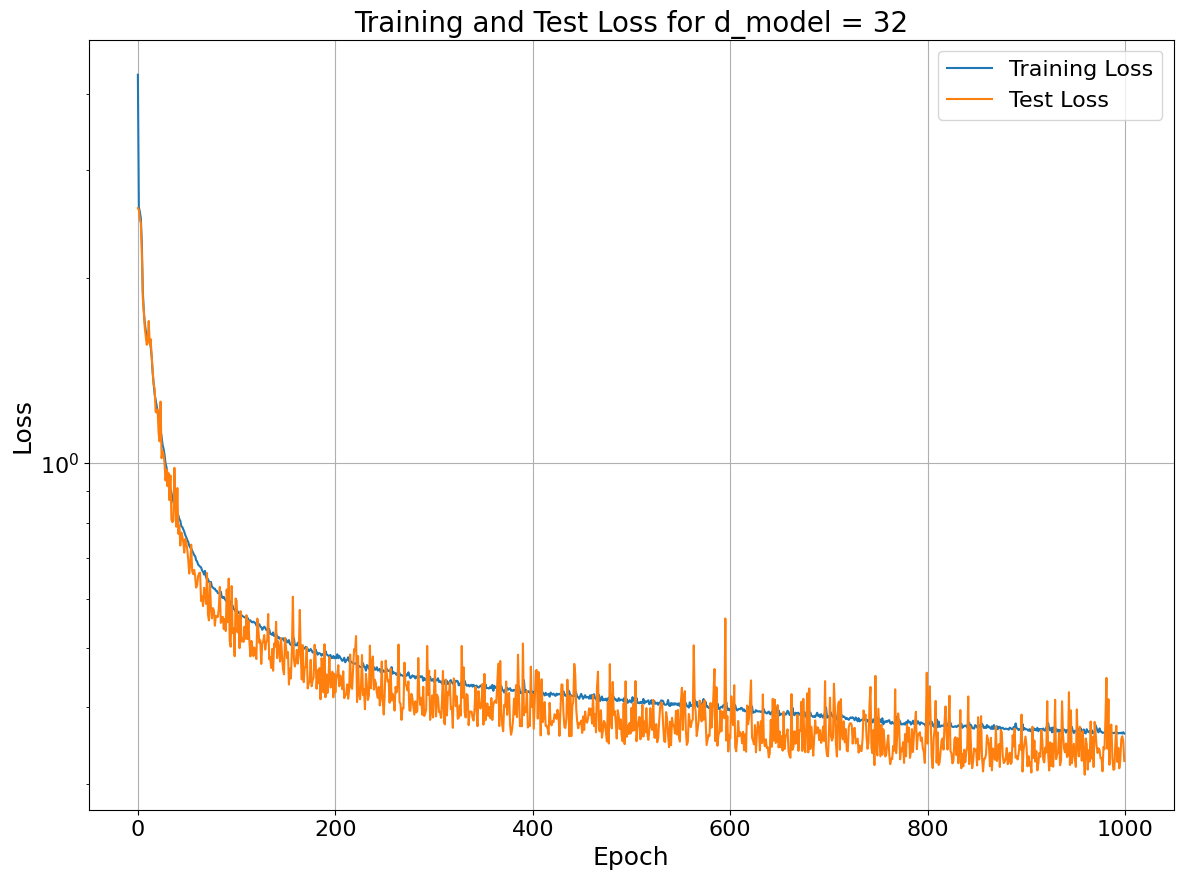

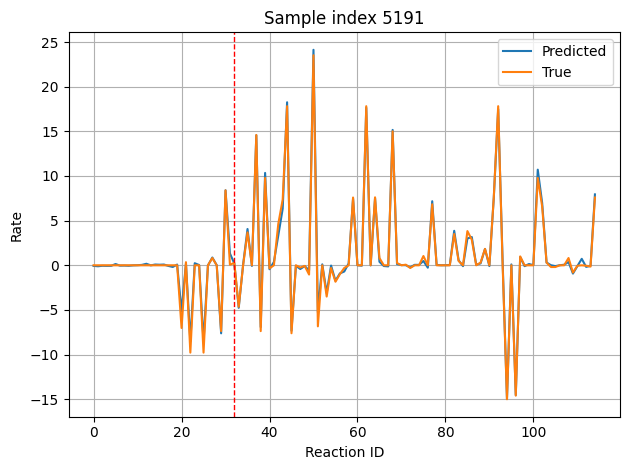

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -77.901886 108.75305
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -77.901886 108.75305
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.36740303 to 3.5746827


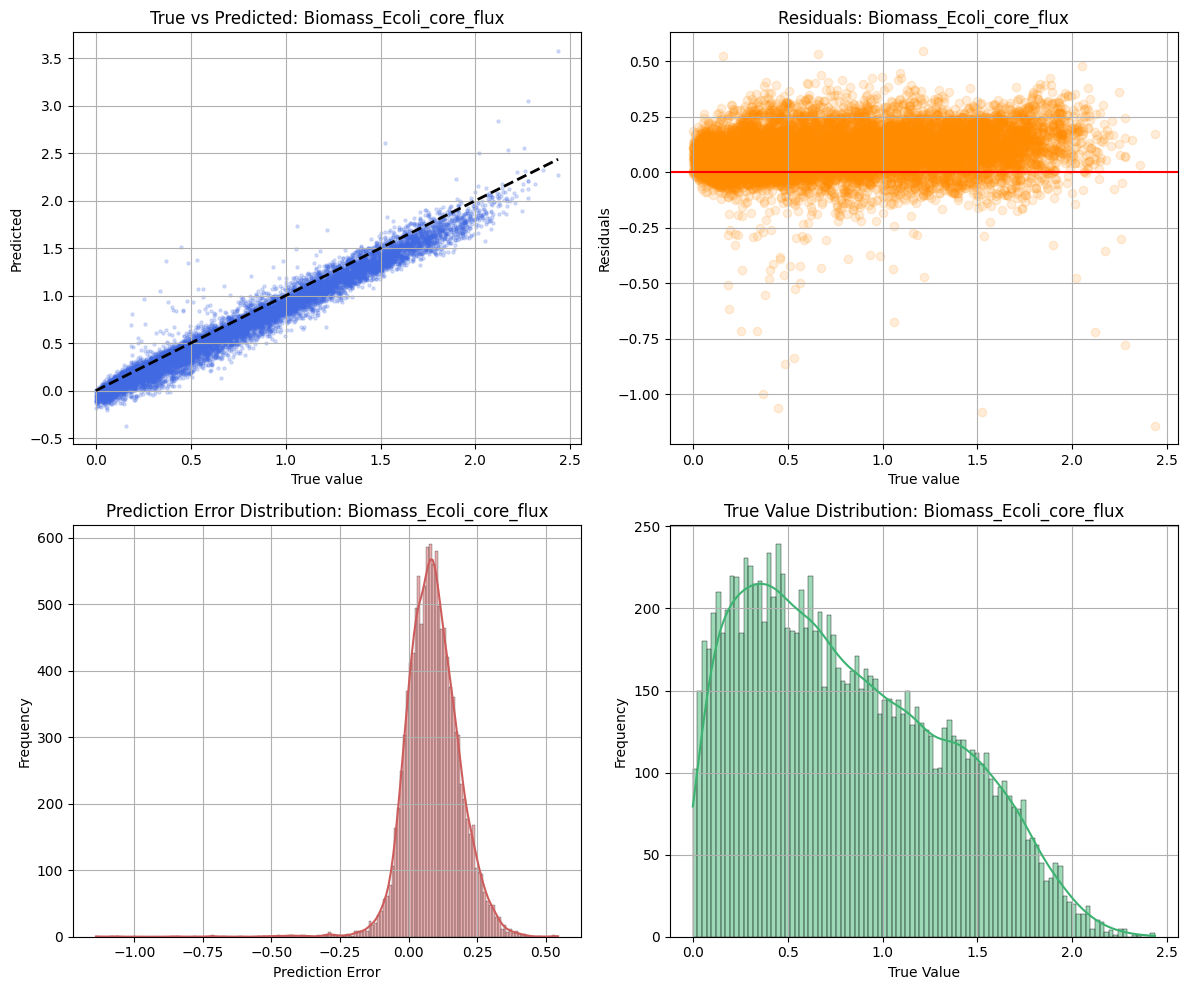

Number of parameters:
29734


In [23]:
train_losses_3222, test_losses_3222, model_3222 = train_model(d_model=32, n_heads=2, n_layers=2, d_ff=128)

plot_loss_curves(train_losses_3222, test_losses_3222, d_model=32)

plot_prediction_sample(X_test, y_test, model_3222)

plot_flux(model_3222, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_3222.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.503951 | Test Loss: 0.412661
Epoch 200/1000 | Train Loss: 0.417380 | Test Loss: 0.384365
Epoch 300/1000 | Train Loss: 0.383342 | Test Loss: 0.324422
Epoch 400/1000 | Train Loss: 0.374655 | Test Loss: 0.310613
Epoch 500/1000 | Train Loss: 0.361911 | Test Loss: 0.335092
Epoch 600/1000 | Train Loss: 0.350327 | Test Loss: 0.307931
Epoch 700/1000 | Train Loss: 0.347879 | Test Loss: 0.300386
Epoch 800/1000 | Train Loss: 0.338352 | Test Loss: 0.290236
Epoch 900/1000 | Train Loss: 0.331290 | Test Loss: 0.288361
Epoch 1000/1000 | Train Loss: 0.326863 | Test Loss: 0.306170
Training Completed.
Training took 60 min 55.7 sec.


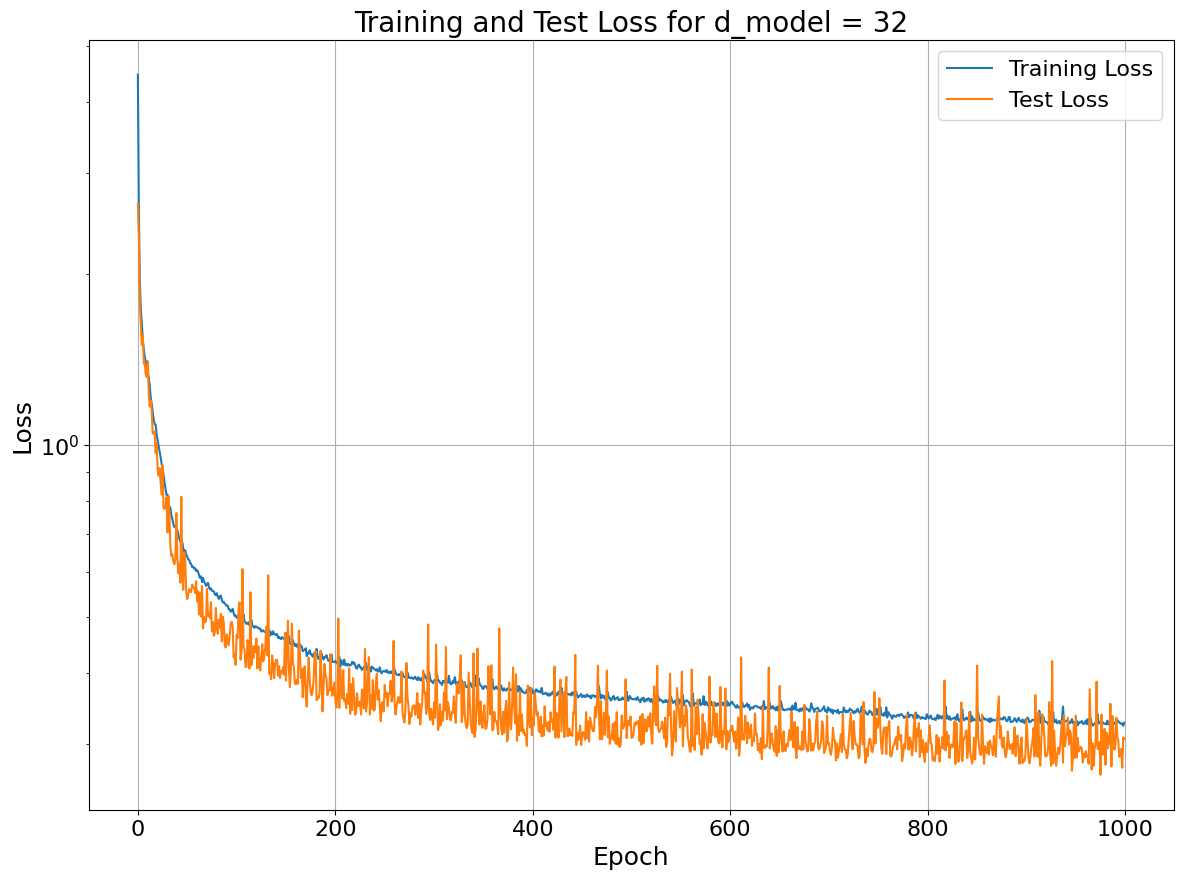

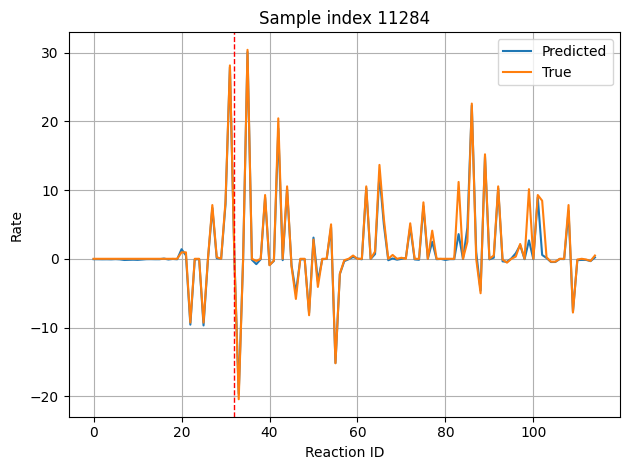

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -75.28316 108.887344
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -75.28316 108.887344
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.4803456 to 2.605379


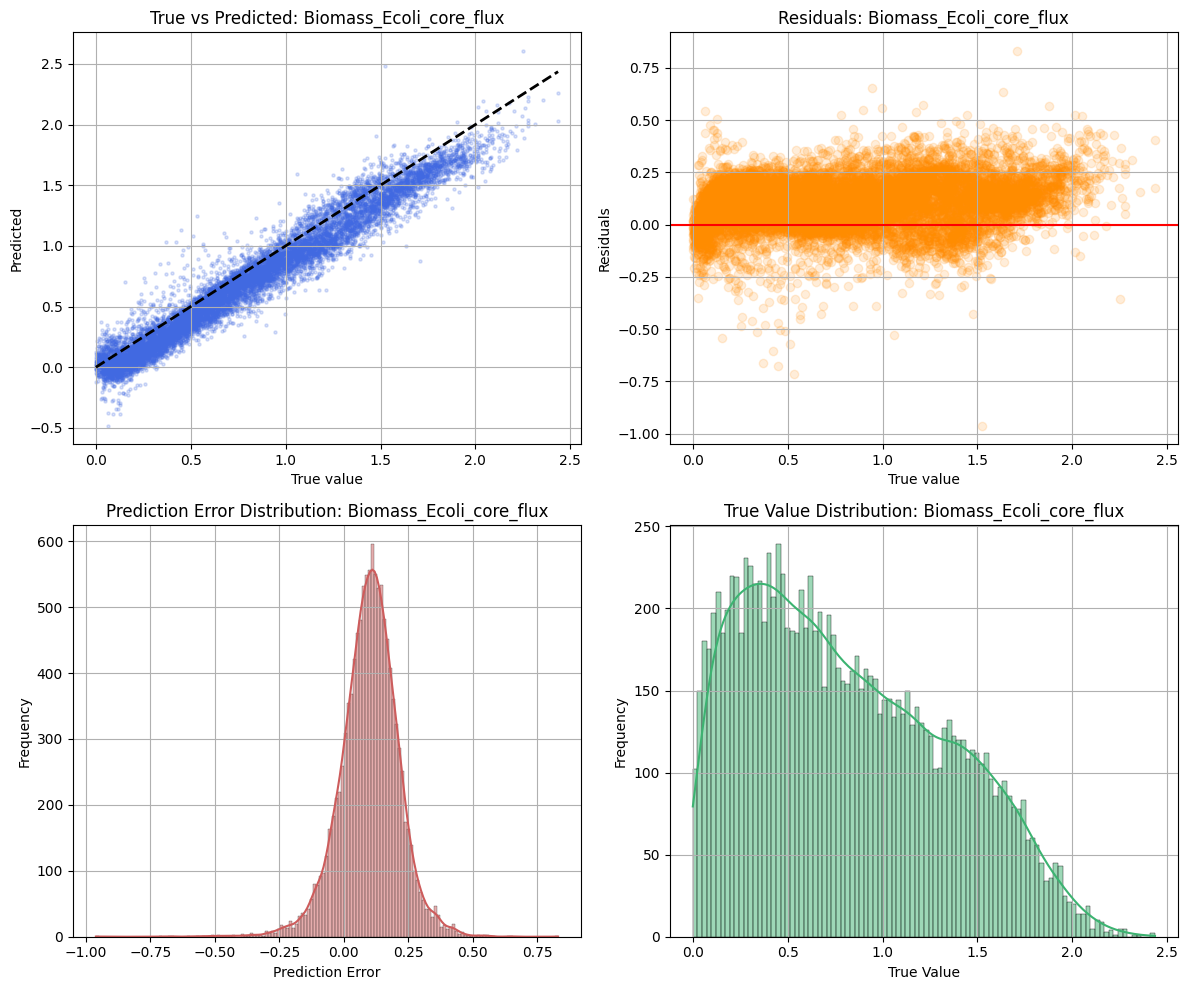

Number of parameters:
29734


In [24]:
train_losses_3242, test_losses_3242, model_3242 = train_model(d_model=32, n_heads=4, n_layers=2, d_ff=128)

plot_loss_curves(train_losses_3242, test_losses_3242, d_model=32)

plot_prediction_sample(X_test, y_test, model_3242)

plot_flux(model_3242, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_3242.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.391318 | Test Loss: 0.346307
Epoch 200/1000 | Train Loss: 0.309769 | Test Loss: 0.304152
Epoch 300/1000 | Train Loss: 0.280483 | Test Loss: 0.343033
Epoch 400/1000 | Train Loss: 0.269562 | Test Loss: 0.280332
Epoch 500/1000 | Train Loss: 0.253622 | Test Loss: 0.250174
Epoch 600/1000 | Train Loss: 0.311674 | Test Loss: 0.264380
Epoch 700/1000 | Train Loss: 0.239858 | Test Loss: 0.219211
Epoch 800/1000 | Train Loss: 0.229539 | Test Loss: 0.227496
Epoch 900/1000 | Train Loss: 0.238136 | Test Loss: 0.239974
Epoch 1000/1000 | Train Loss: 0.221521 | Test Loss: 0.299163
Training Completed.
Training took 90 min 14.7 sec.


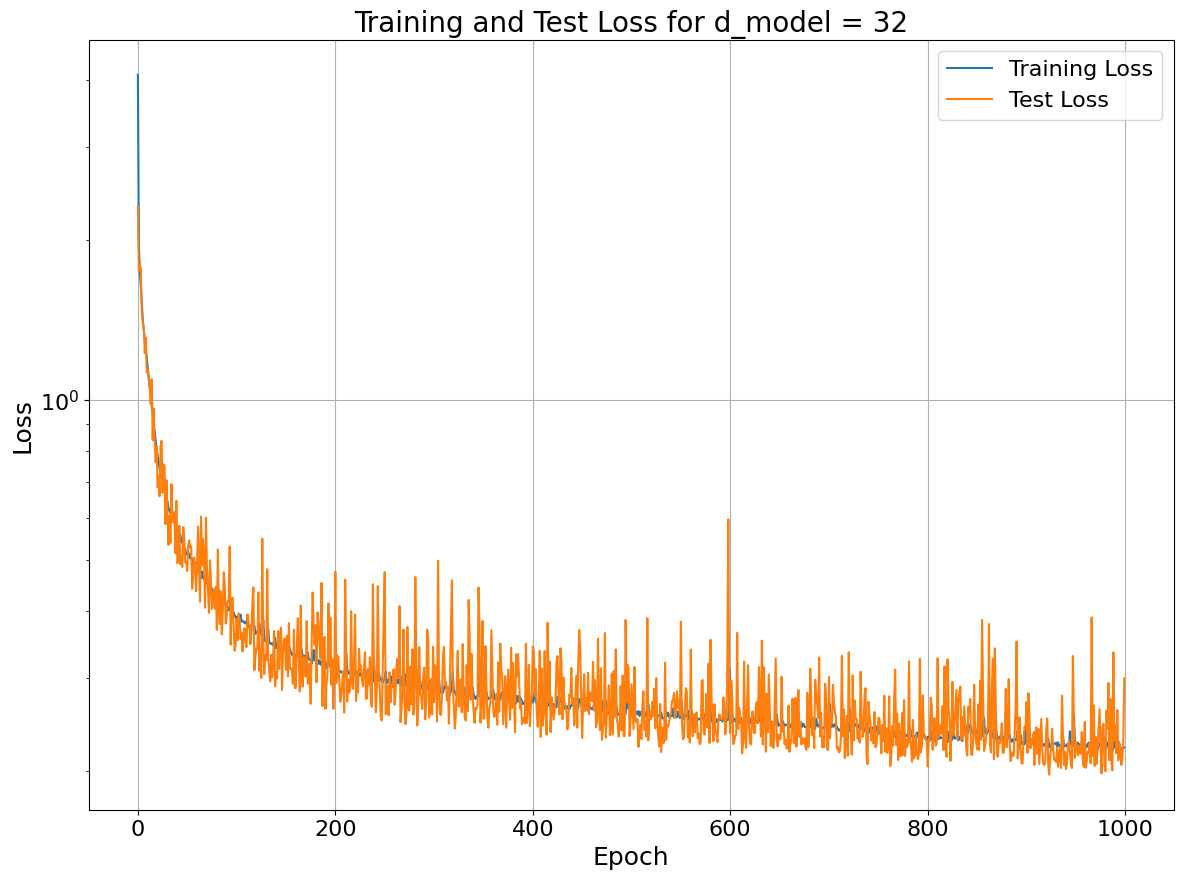

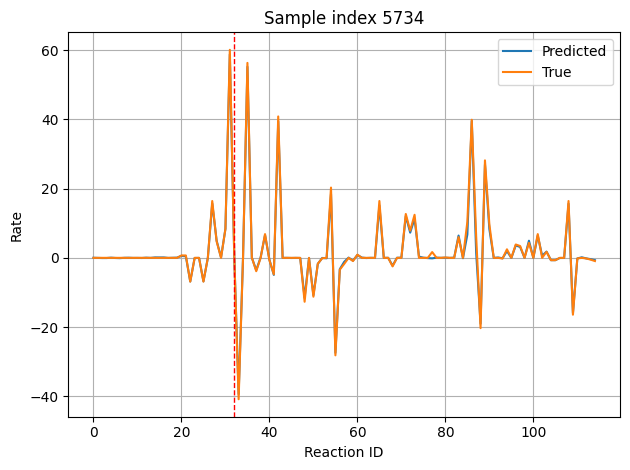

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -75.27248 106.3234
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -75.27248 106.3234
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.358837 to 2.0357032


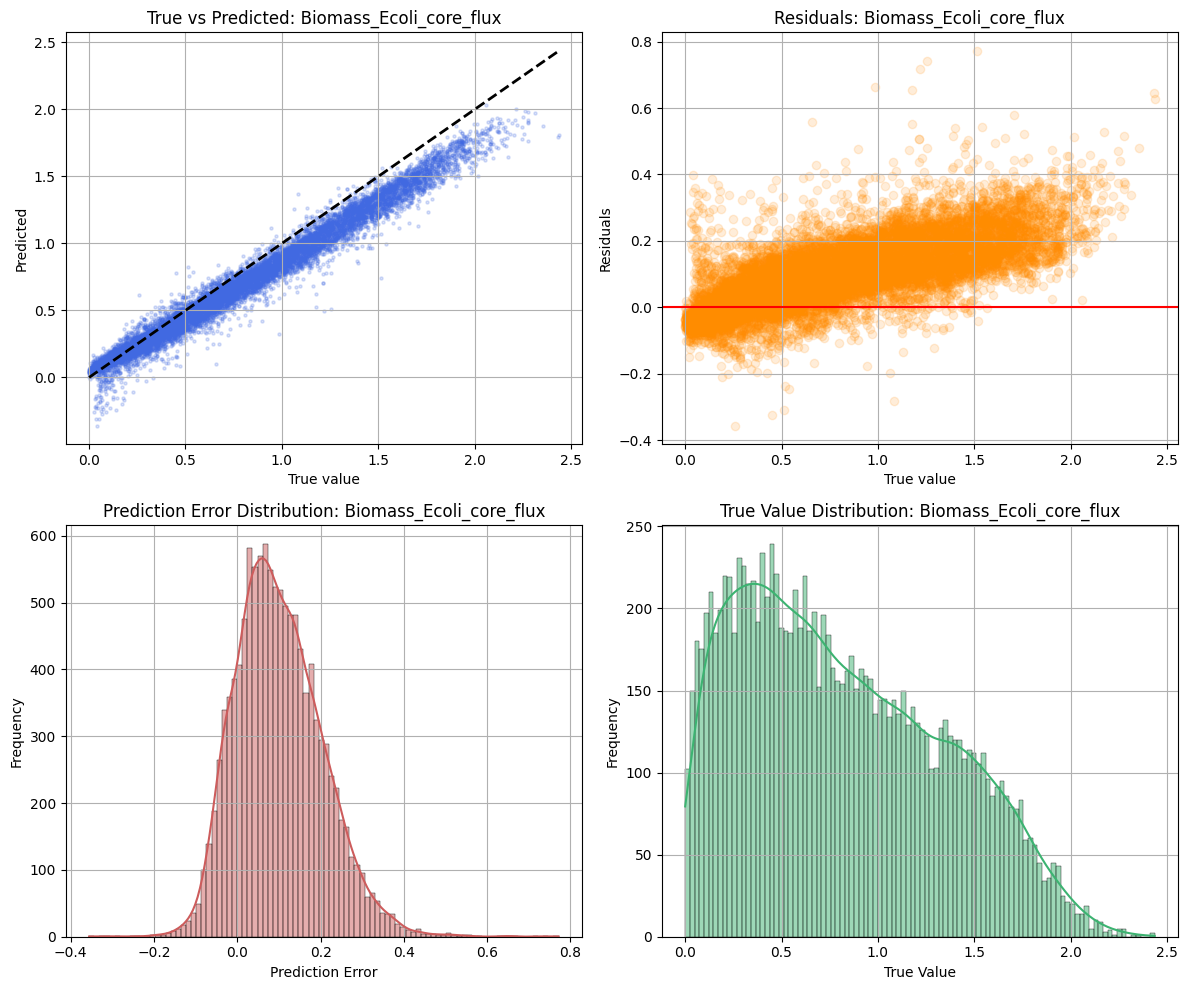

Number of parameters:
42761


In [25]:
train_losses_3243, test_losses_3243, model_3243 = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=128)

plot_loss_curves(train_losses_3243, test_losses_3243, d_model=32)

plot_prediction_sample(X_test, y_test, model_3243)

plot_flux(model_3243, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.366446 | Test Loss: 0.402784
Epoch 200/1000 | Train Loss: 0.287858 | Test Loss: 0.264329
Epoch 300/1000 | Train Loss: 0.249278 | Test Loss: 0.261842
Epoch 400/1000 | Train Loss: 0.234931 | Test Loss: 0.311917
Epoch 500/1000 | Train Loss: 0.224490 | Test Loss: 0.231561
Epoch 600/1000 | Train Loss: 0.215776 | Test Loss: 0.222827
Epoch 700/1000 | Train Loss: 0.215439 | Test Loss: 0.239723
Epoch 800/1000 | Train Loss: 0.208256 | Test Loss: 0.233335
Epoch 900/1000 | Train Loss: 0.205749 | Test Loss: 0.231077
Epoch 1000/1000 | Train Loss: 0.200440 | Test Loss: 0.203314
Training Completed.
Training took 99 min 55.1 sec.


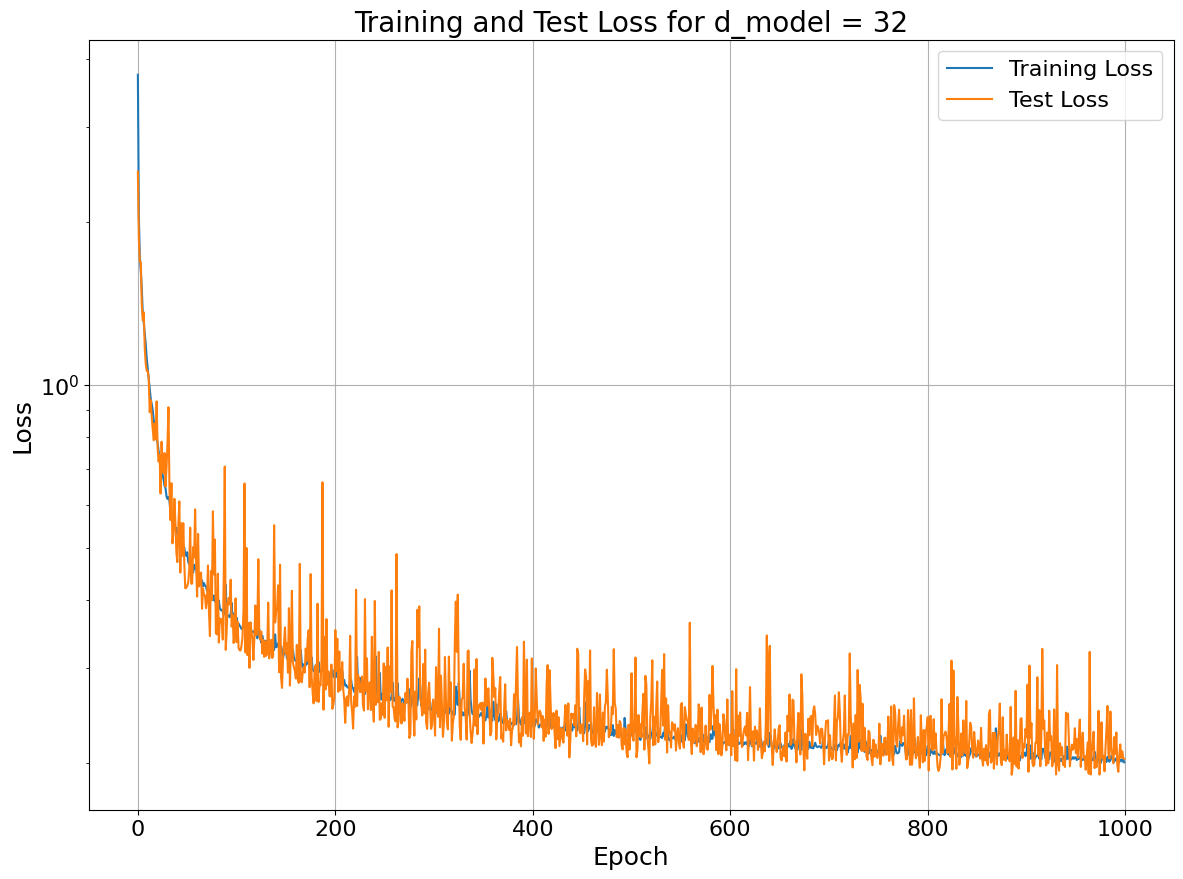

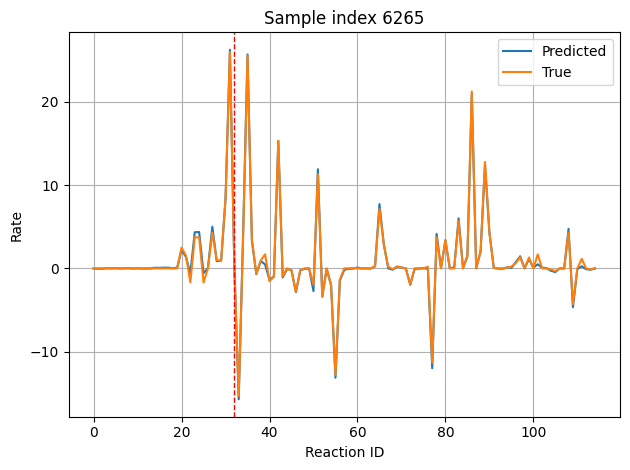

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -76.98723 109.46447
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -76.98723 109.46447
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.15815258 to 2.3522587


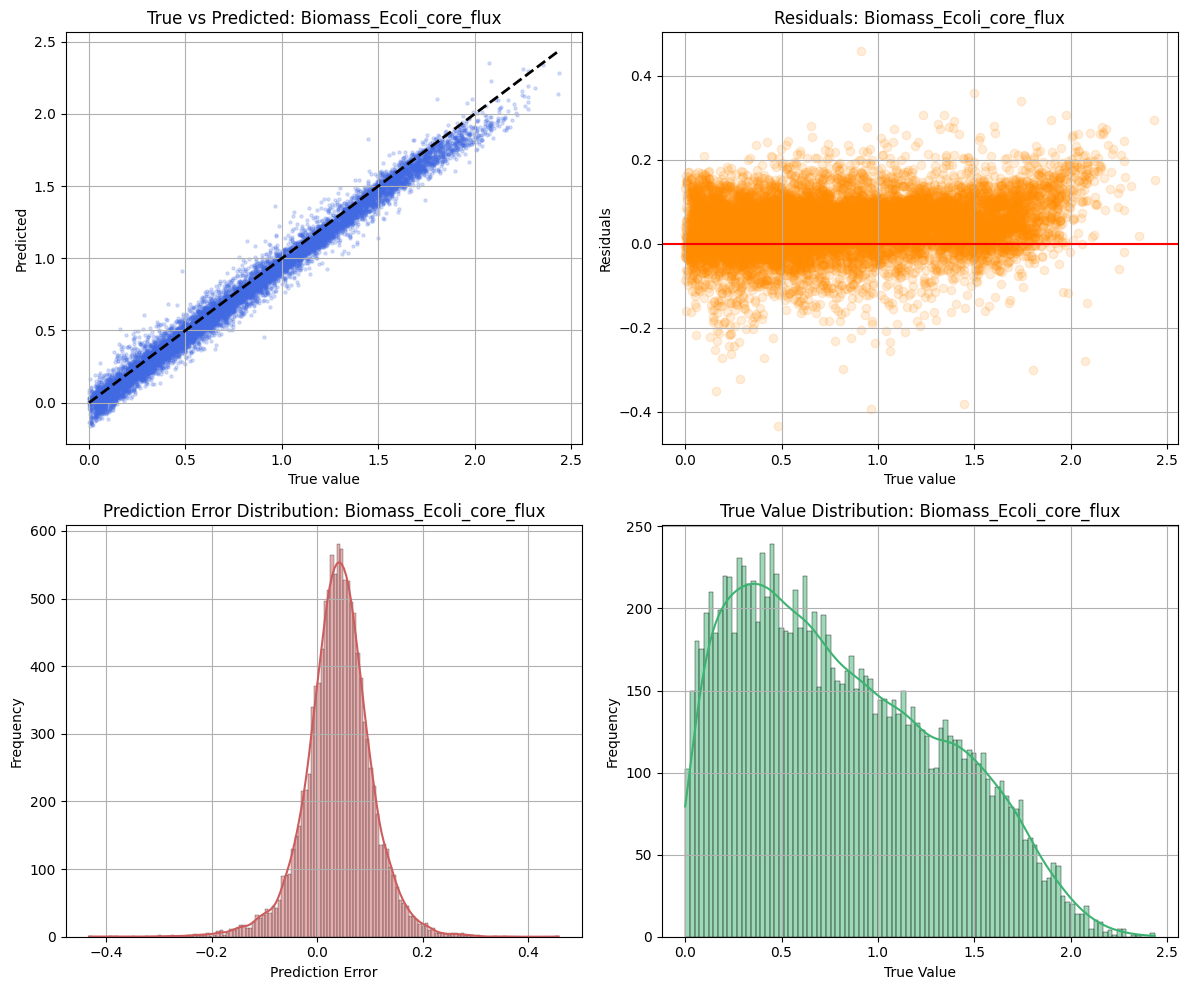

Number of parameters:
68489


In [27]:
train_losses_3243_256, test_losses_3243_256, model_3243_256 = train_model(d_model=32, n_heads=4, n_layers=3, d_ff=256)

plot_loss_curves(train_losses_3243_256, test_losses_3243_256, d_model=32)

plot_prediction_sample(X_test, y_test, model_3243_256)

plot_flux(model_3243_256, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_3243_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.439502 | Test Loss: 0.389804
Epoch 200/1000 | Train Loss: 0.372673 | Test Loss: 0.379483
Epoch 300/1000 | Train Loss: 0.333117 | Test Loss: 0.351369
Epoch 400/1000 | Train Loss: 0.318646 | Test Loss: 0.315151
Epoch 500/1000 | Train Loss: 0.308253 | Test Loss: 0.287957
Epoch 600/1000 | Train Loss: 0.292949 | Test Loss: 0.302768
Epoch 700/1000 | Train Loss: 0.284054 | Test Loss: 0.284333
Epoch 800/1000 | Train Loss: 0.279455 | Test Loss: 0.277063
Epoch 900/1000 | Train Loss: 0.268785 | Test Loss: 0.261409
Epoch 1000/1000 | Train Loss: 0.266091 | Test Loss: 0.246374
Training Completed.
Training took 68 min 51.2 sec.


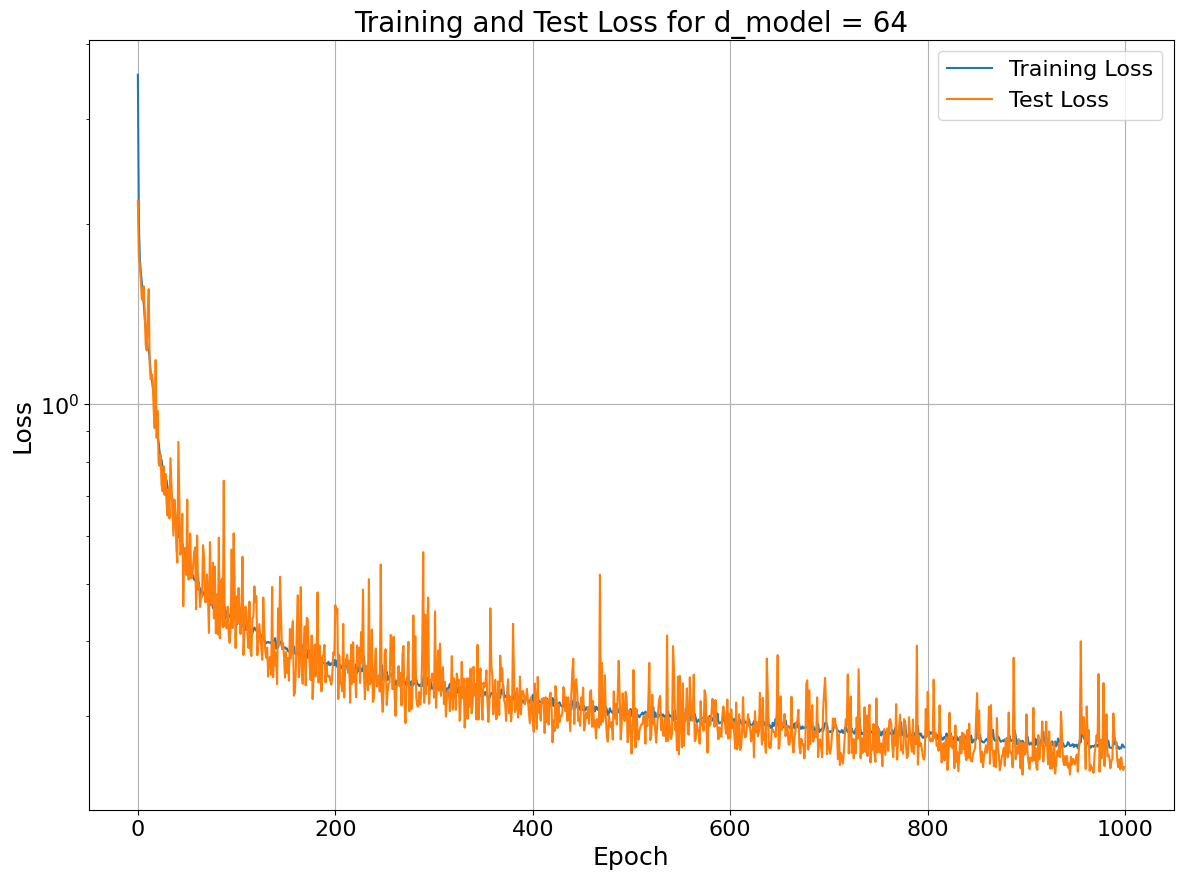

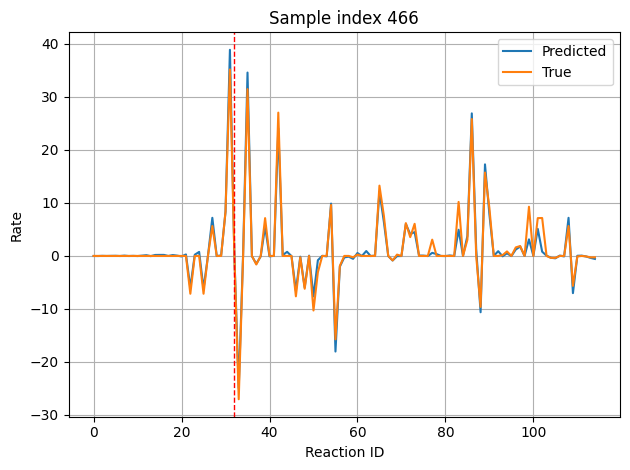

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -77.719475 110.31573
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -77.719475 110.31573
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.29358172 to 2.5730183


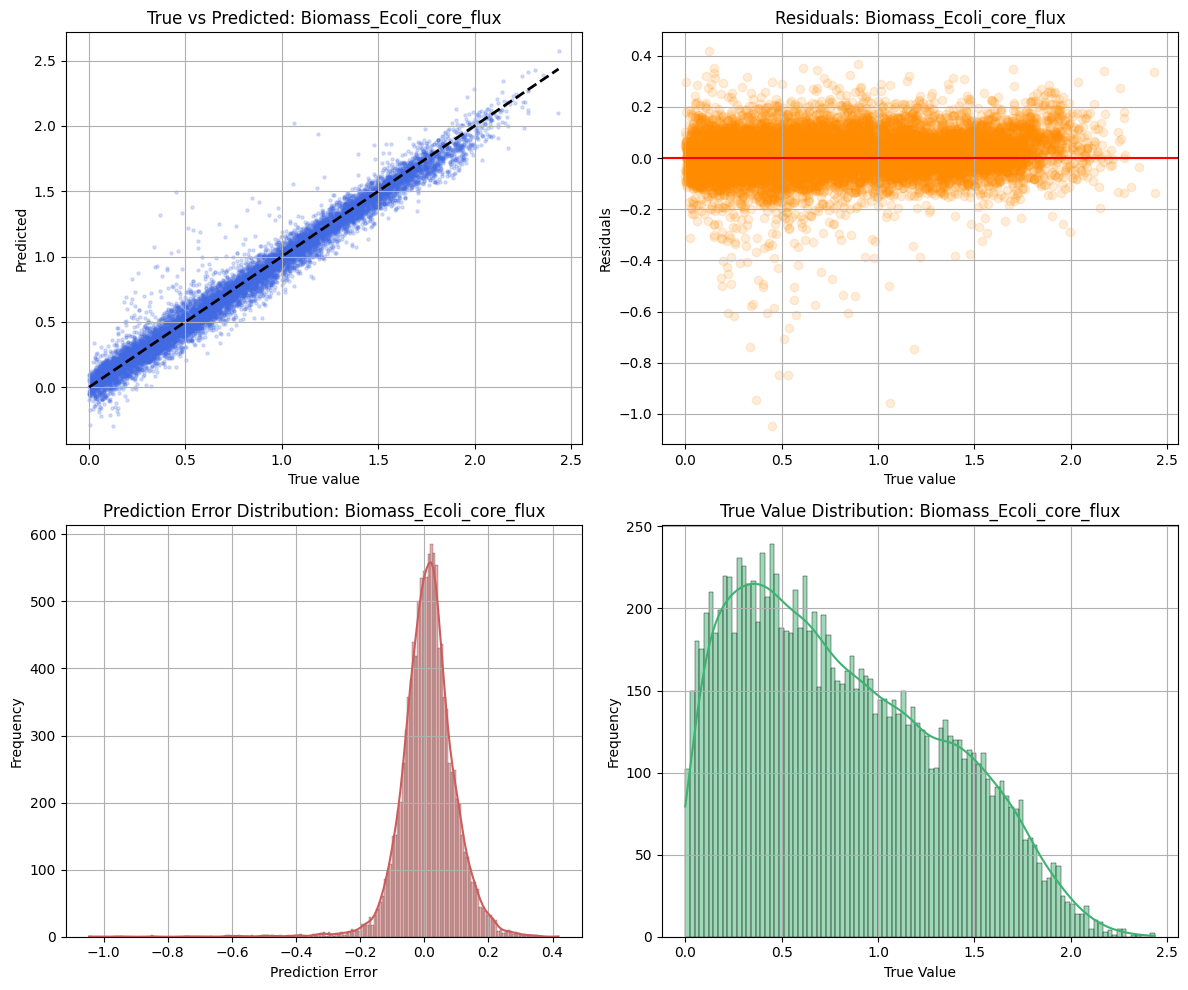

Number of parameters:
108614


In [28]:
train_losses_6422_256, test_losses_6422_256, model_6422_256 = train_model(d_model=64, n_heads=2, n_layers=2, d_ff=256)

plot_loss_curves(train_losses_6422_256, test_losses_6422_256, d_model=64)

plot_prediction_sample(X_test, y_test, model_6422_256)

plot_flux(model_6422_256, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6422_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.376714 | Test Loss: 0.433265
Epoch 200/1000 | Train Loss: 0.324101 | Test Loss: 0.287602
Epoch 300/1000 | Train Loss: 0.292942 | Test Loss: 0.283904
Epoch 400/1000 | Train Loss: 0.279050 | Test Loss: 0.260209
Epoch 500/1000 | Train Loss: 0.270640 | Test Loss: 0.261027
Epoch 600/1000 | Train Loss: 0.259391 | Test Loss: 0.251417
Epoch 700/1000 | Train Loss: 0.252459 | Test Loss: 0.294906
Epoch 800/1000 | Train Loss: 0.250138 | Test Loss: 0.264902
Epoch 900/1000 | Train Loss: 0.246647 | Test Loss: 0.268296
Epoch 1000/1000 | Train Loss: 0.242432 | Test Loss: 0.232005
Training Completed.
Training took 84 min 49.5 sec.


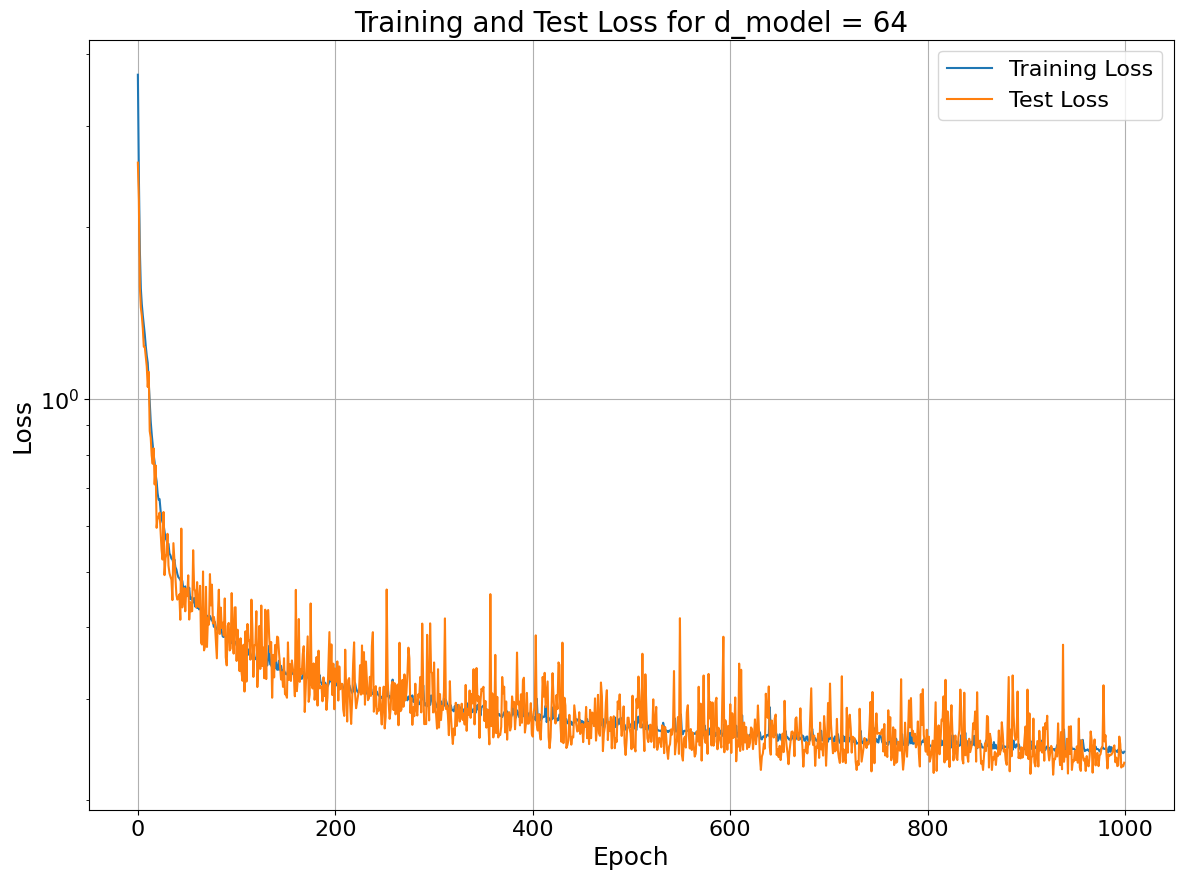

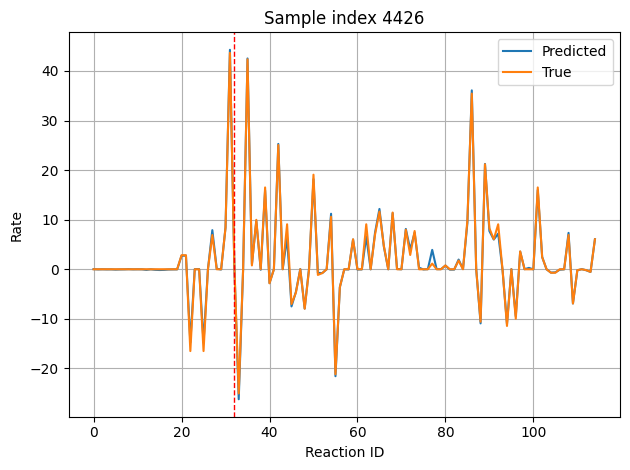

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -77.276184 108.12402
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -77.276184 108.12402
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.06145954 to 2.4949322


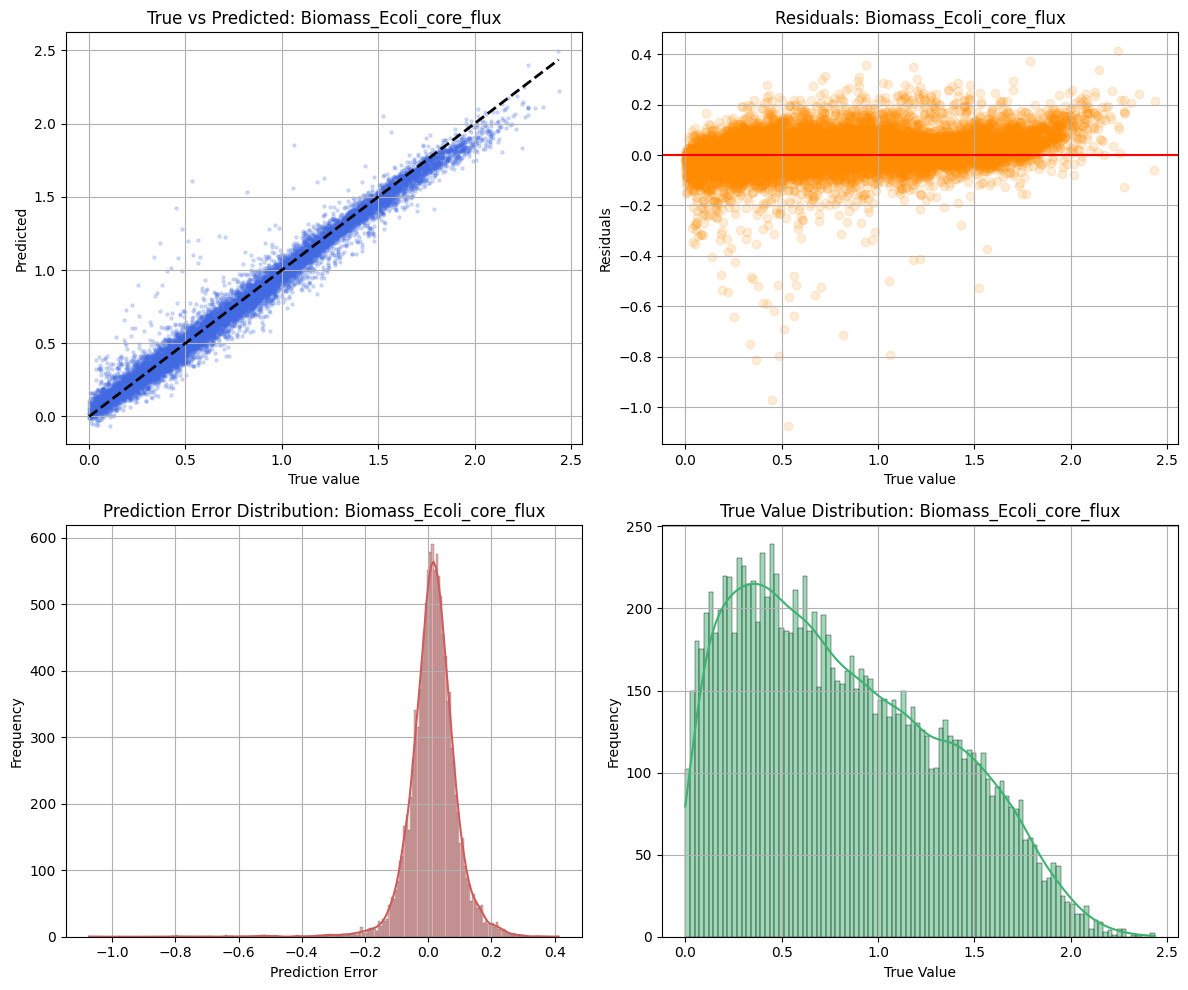

Number of parameters:
108614


In [29]:
train_losses_6442_256, test_losses_6442_256, model_6442_256 = train_model(d_model=64, n_heads=4, n_layers=2, d_ff=256)

plot_loss_curves(train_losses_6442_256, test_losses_6442_256, d_model=64)

plot_prediction_sample(X_test, y_test, model_6442_256)

plot_flux(model_6442_256, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6442_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.275813 | Test Loss: 0.340277
Epoch 200/1000 | Train Loss: 0.233368 | Test Loss: 0.251904
Epoch 300/1000 | Train Loss: 0.210919 | Test Loss: 0.210116
Epoch 400/1000 | Train Loss: 0.195732 | Test Loss: 0.187198
Epoch 500/1000 | Train Loss: 0.188846 | Test Loss: 0.194856
Epoch 600/1000 | Train Loss: 0.184532 | Test Loss: 0.209320
Epoch 700/1000 | Train Loss: 0.177774 | Test Loss: 0.212844
Epoch 800/1000 | Train Loss: 0.173560 | Test Loss: 0.188093
Epoch 900/1000 | Train Loss: 0.181352 | Test Loss: 0.194998
Epoch 1000/1000 | Train Loss: 0.166434 | Test Loss: 0.205774
Training Completed.
Training took 121 min 3.8 sec.


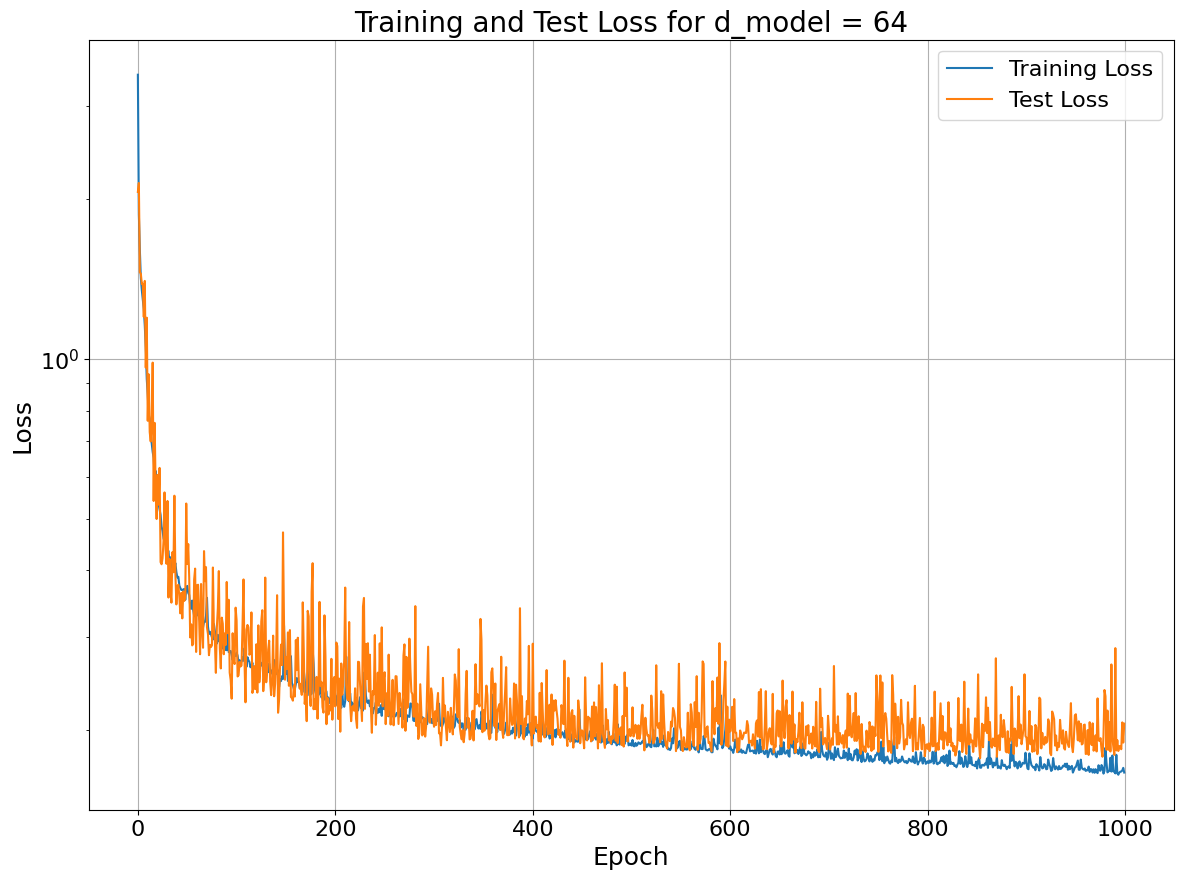

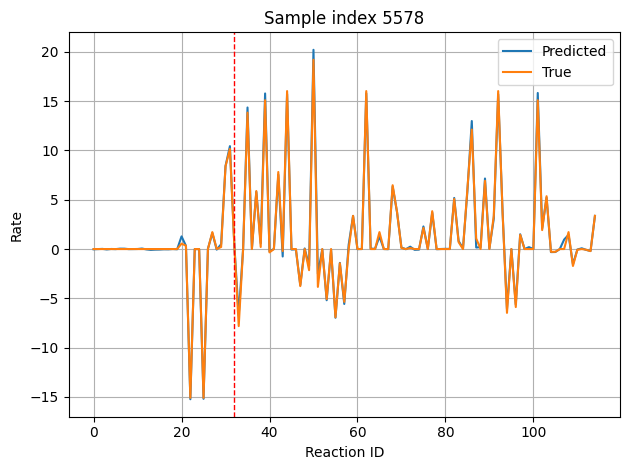

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -76.20085 109.51695
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -76.20085 109.51695
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.12148756 to 2.2351308


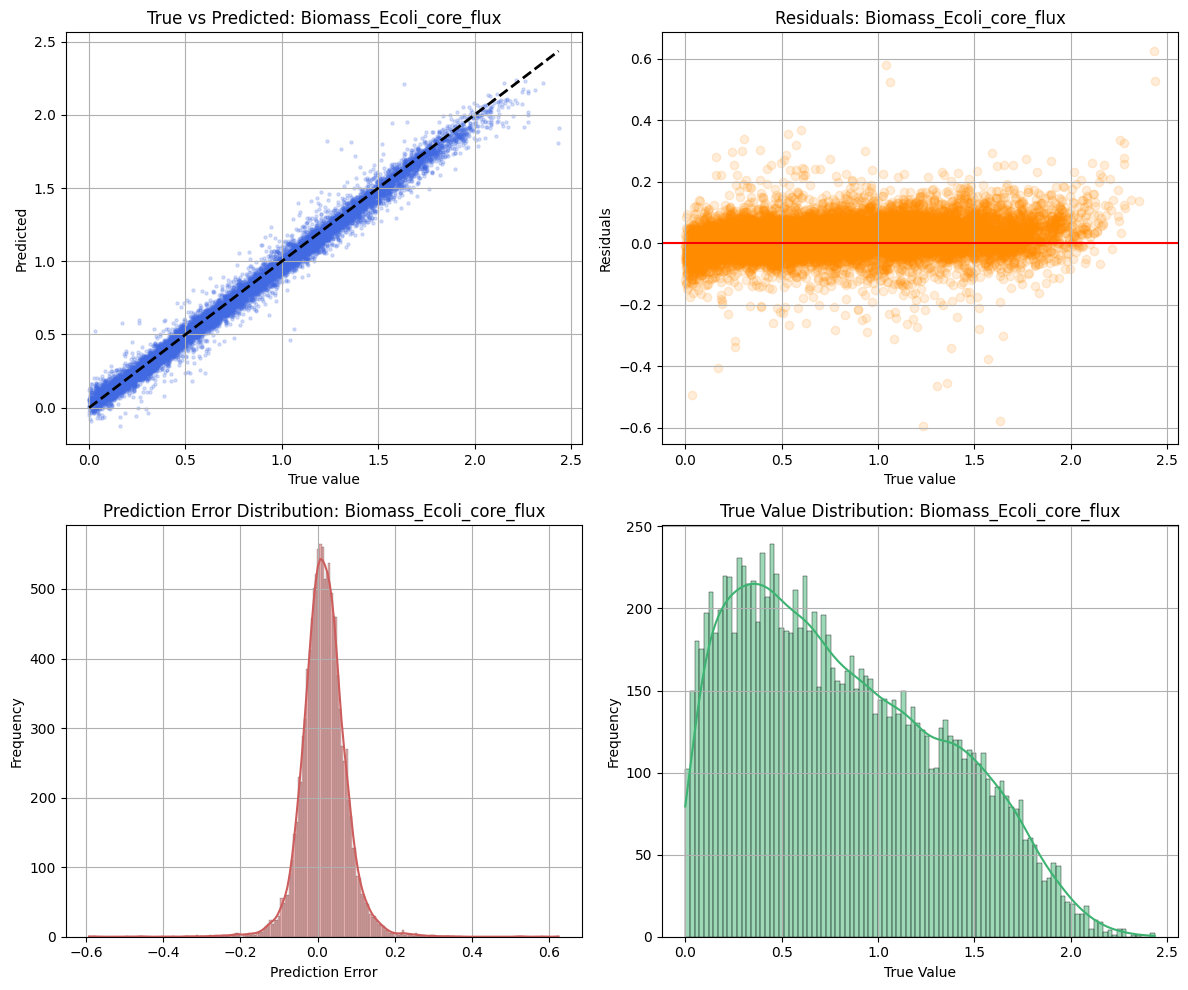

Number of parameters:
159241


In [30]:
train_losses_6443_256, test_losses_6443_256, model_6443_256 = train_model(d_model=64, n_heads=4, n_layers=3, d_ff=256)

plot_loss_curves(train_losses_6443_256, test_losses_6443_256, d_model=64)

plot_prediction_sample(X_test, y_test, model_6443_256)

plot_flux(model_6443_256, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6443_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.263812 | Test Loss: 0.449606
Epoch 200/1000 | Train Loss: 0.217368 | Test Loss: 0.302488
Epoch 300/1000 | Train Loss: 0.202310 | Test Loss: 0.195380
Epoch 400/1000 | Train Loss: 0.202153 | Test Loss: 0.361152
Epoch 500/1000 | Train Loss: 0.179025 | Test Loss: 0.193948
Epoch 600/1000 | Train Loss: 0.173606 | Test Loss: 0.193681
Epoch 700/1000 | Train Loss: 0.166102 | Test Loss: 0.216286
Epoch 800/1000 | Train Loss: 0.164288 | Test Loss: 0.193472
Epoch 900/1000 | Train Loss: 0.161550 | Test Loss: 0.217393
Epoch 1000/1000 | Train Loss: 0.151901 | Test Loss: 0.191087
Training Completed.
Training took 162 min 42.8 sec.


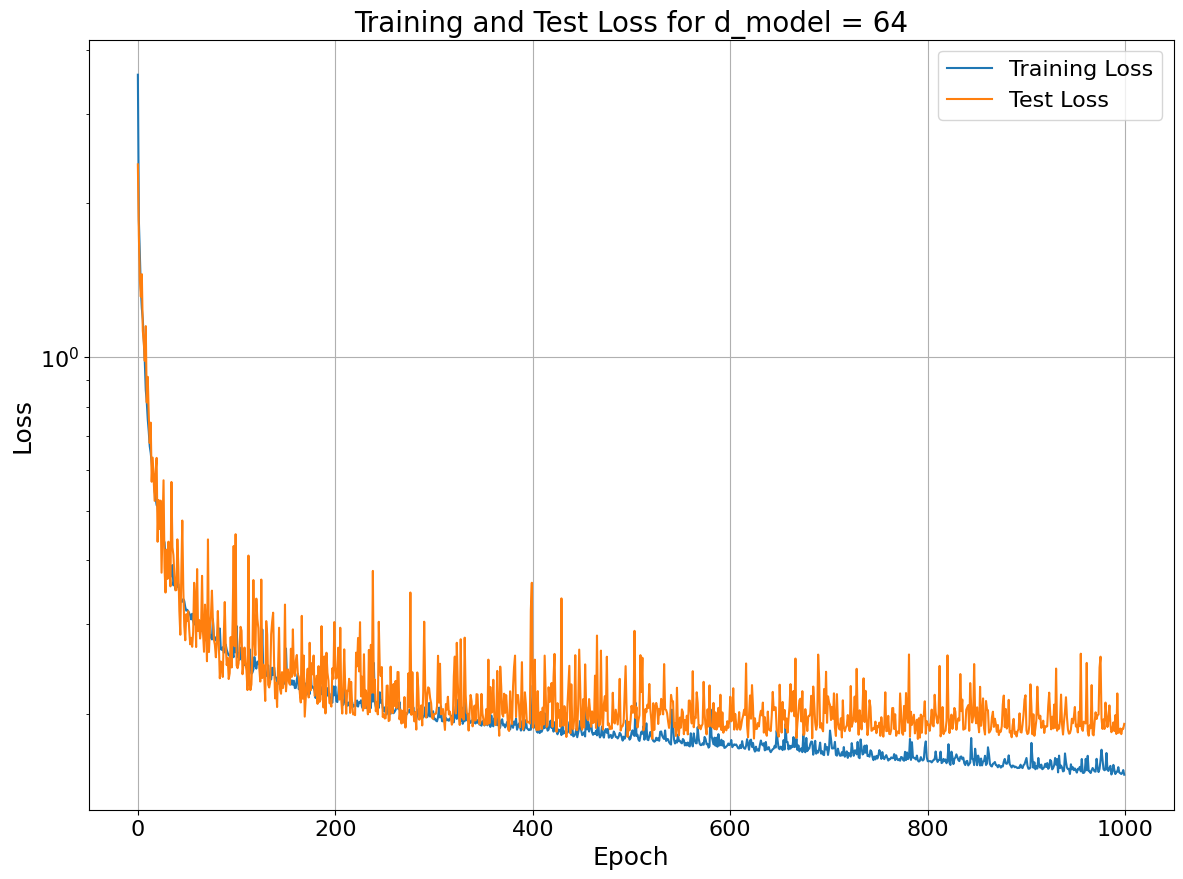

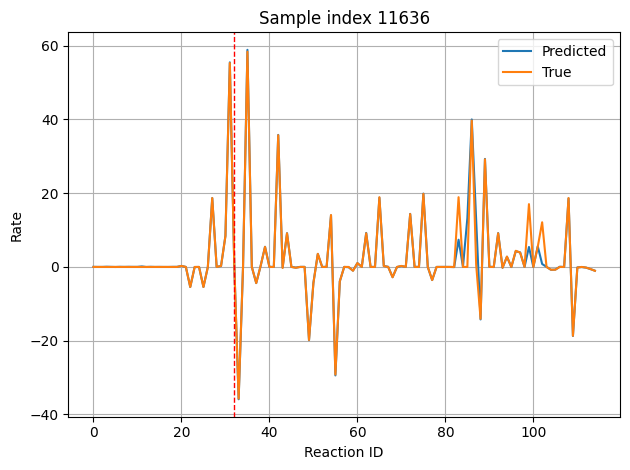

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -78.52295 109.9946
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -78.52295 109.9946
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.26993018 to 2.3270824


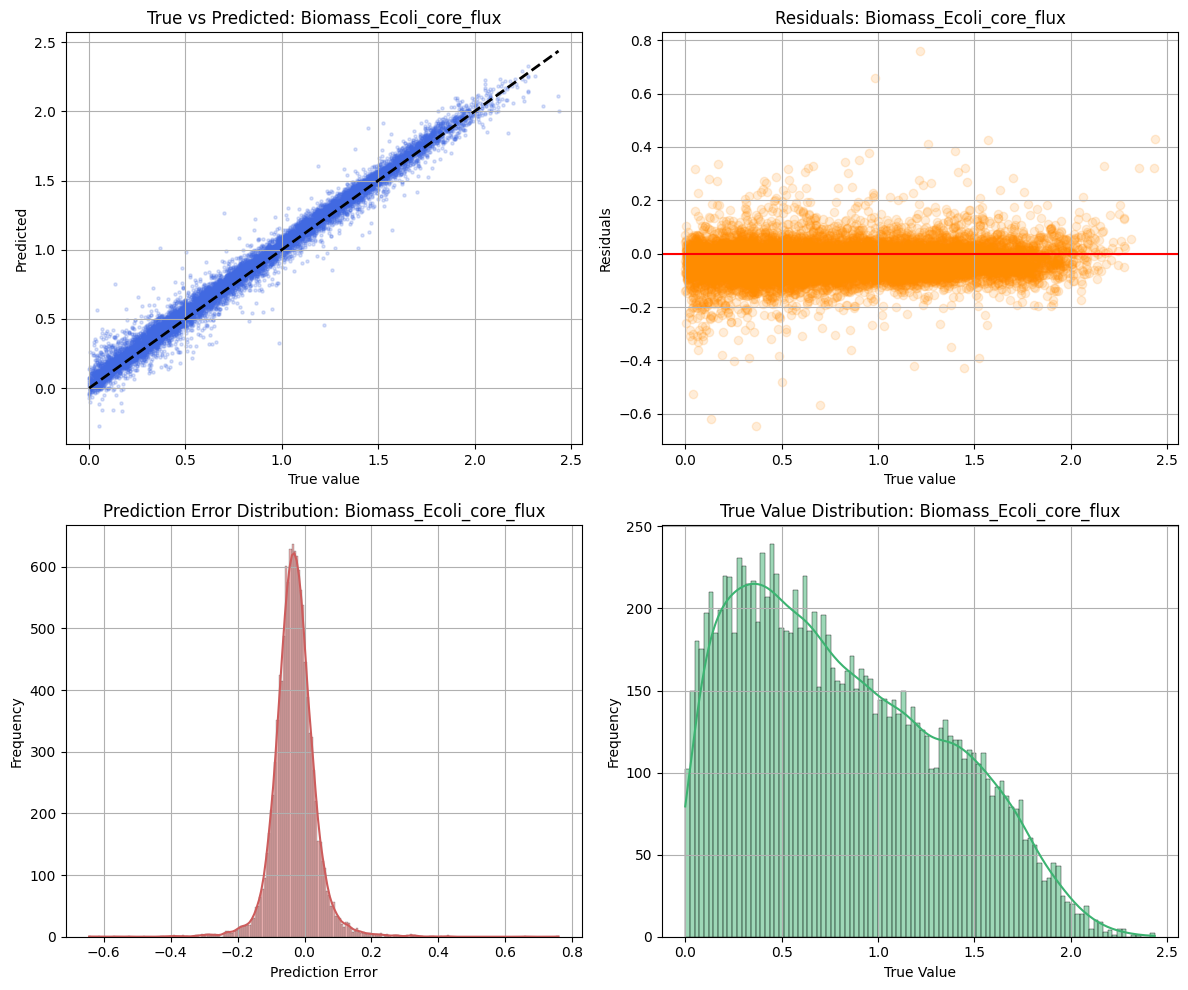

Number of parameters:
159241


In [31]:
train_losses_6483_256, test_losses_6483_256, model_6483_256 = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=256)

plot_loss_curves(train_losses_6483_256, test_losses_6483_256, d_model=64)

plot_prediction_sample(X_test, y_test, model_6483_256)

plot_flux(model_6483_256, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.241910 | Test Loss: 0.287174
Epoch 200/1000 | Train Loss: 0.199969 | Test Loss: 0.196459
Epoch 300/1000 | Train Loss: 0.187503 | Test Loss: 0.213286
Epoch 400/1000 | Train Loss: 0.176814 | Test Loss: 0.186815
Epoch 500/1000 | Train Loss: 0.173960 | Test Loss: 0.197527
Epoch 600/1000 | Train Loss: 0.155079 | Test Loss: 0.232100
Epoch 700/1000 | Train Loss: 0.146005 | Test Loss: 0.212297
Epoch 800/1000 | Train Loss: 0.134967 | Test Loss: 0.191725
Epoch 900/1000 | Train Loss: 0.135851 | Test Loss: 0.202059
Epoch 1000/1000 | Train Loss: 0.128615 | Test Loss: 0.186667
Training Completed.
Training took 173 min 41.2 sec.


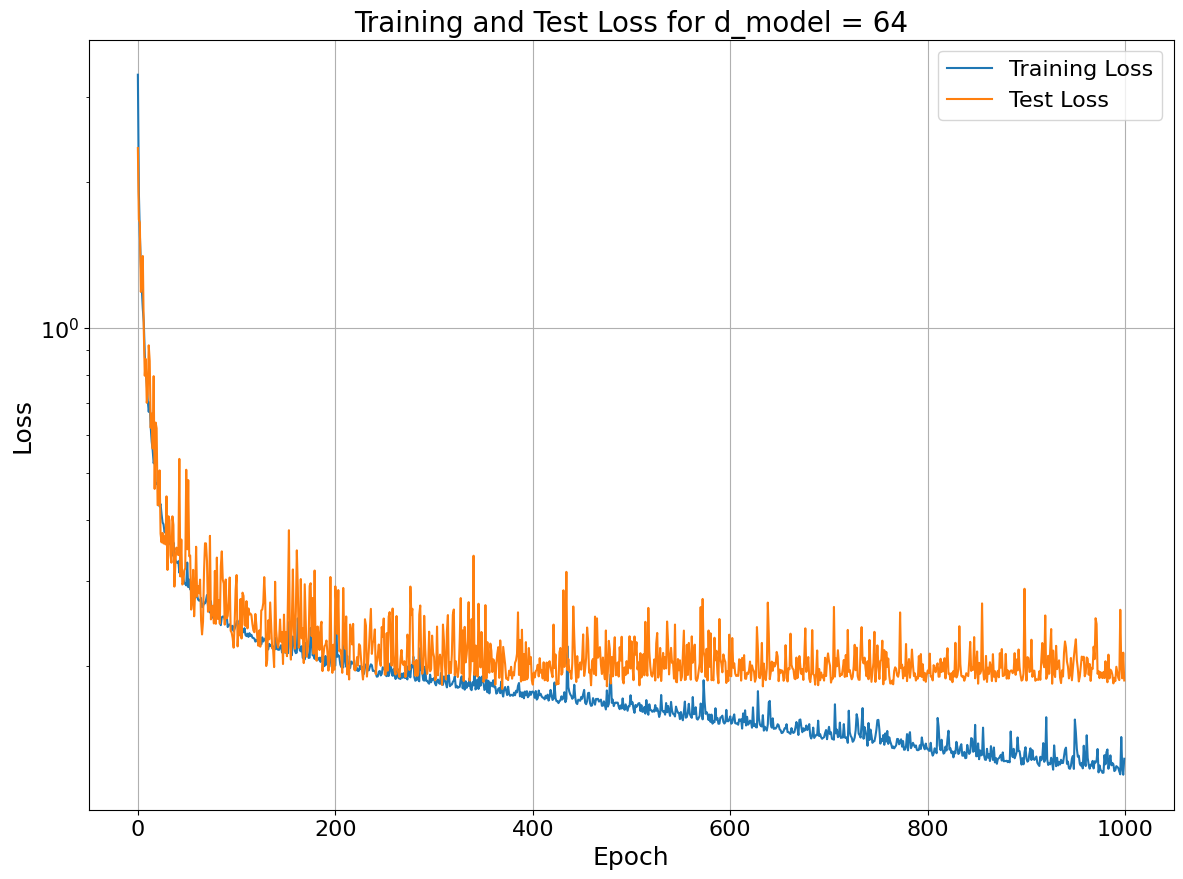

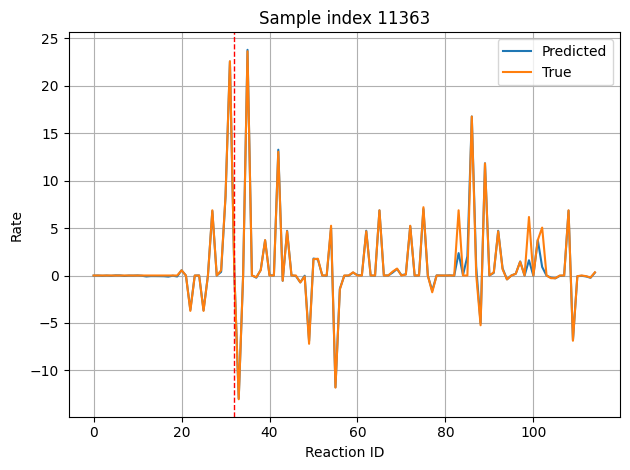

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -78.27769 109.01809
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -78.27769 109.01809
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.09016895 to 2.2843258


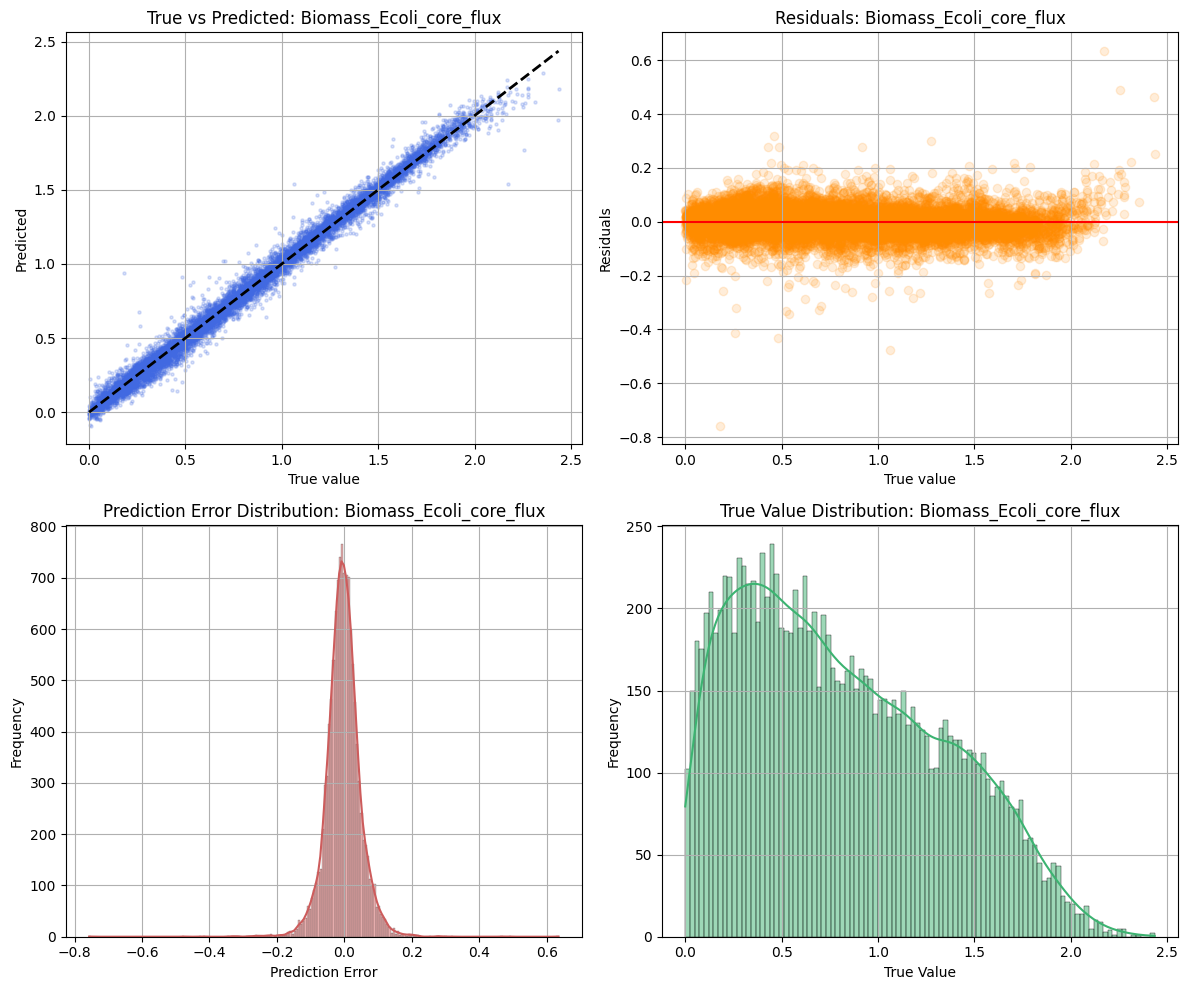

Number of parameters:
259849


In [32]:
train_losses_6483_512, test_losses_6483_512, model_6483_512 = train_model(d_model=64, n_heads=8, n_layers=3, d_ff=512)

plot_loss_curves(train_losses_6483_512, test_losses_6483_512, d_model=64)

plot_prediction_sample(X_test, y_test, model_6483_512)

plot_flux(model_6483_512, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_6483_512.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.315218 | Test Loss: 0.300455
Epoch 200/1000 | Train Loss: 0.257453 | Test Loss: 0.247470
Epoch 300/1000 | Train Loss: 0.252227 | Test Loss: 0.251512
Epoch 400/1000 | Train Loss: 0.233217 | Test Loss: 0.218287
Epoch 500/1000 | Train Loss: 0.220229 | Test Loss: 0.235772
Epoch 600/1000 | Train Loss: 0.219829 | Test Loss: 0.234284
Epoch 700/1000 | Train Loss: 0.216192 | Test Loss: 0.231338
Epoch 800/1000 | Train Loss: 0.229129 | Test Loss: 0.204604
Epoch 900/1000 | Train Loss: 0.206969 | Test Loss: 0.201009
Epoch 1000/1000 | Train Loss: 0.202647 | Test Loss: 0.203262
Training Completed.
Training took 111 min 30.8 sec.


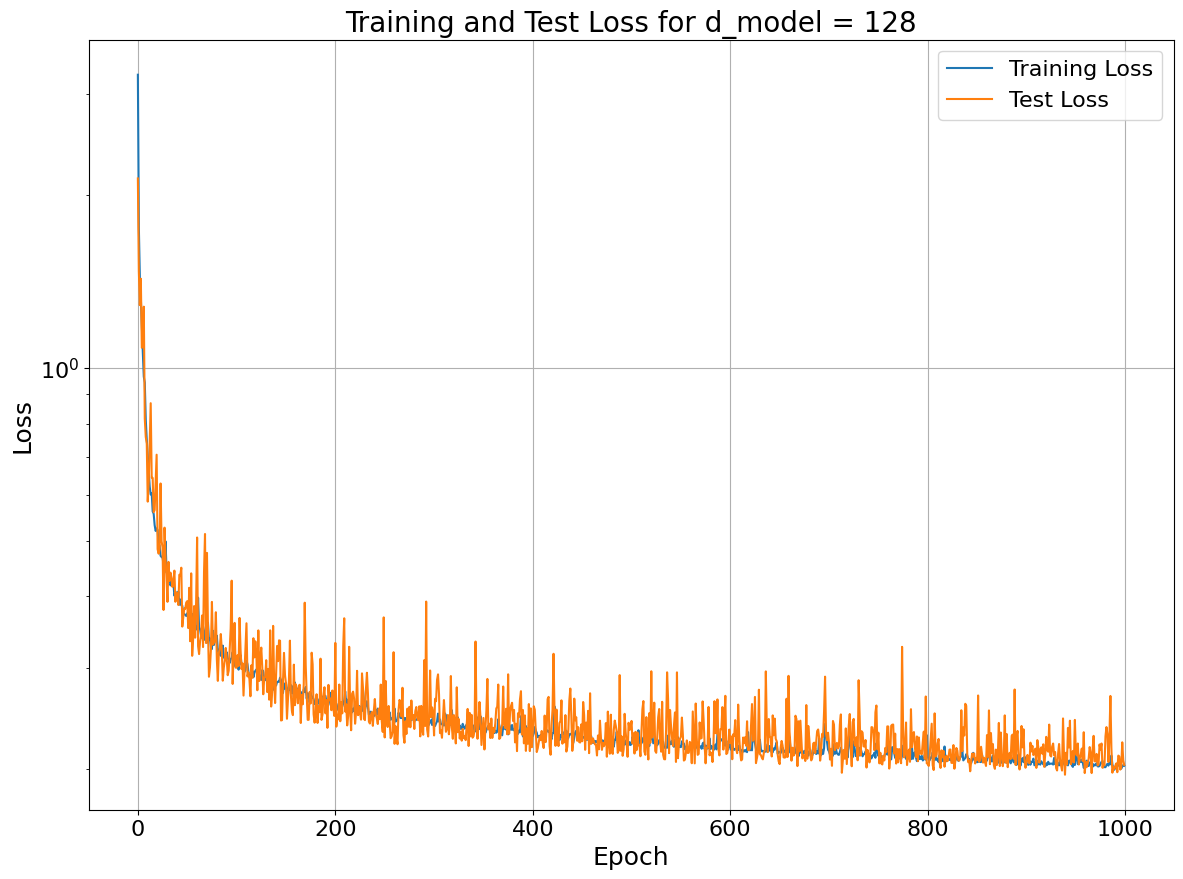

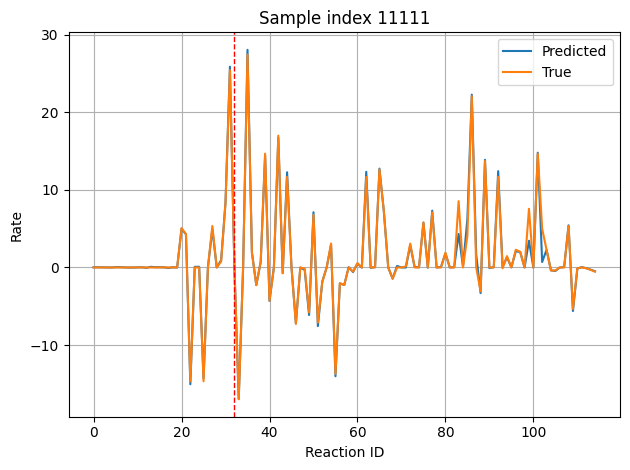

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -78.99503 108.65804
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -78.99503 108.65804
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.16594756 to 2.170238


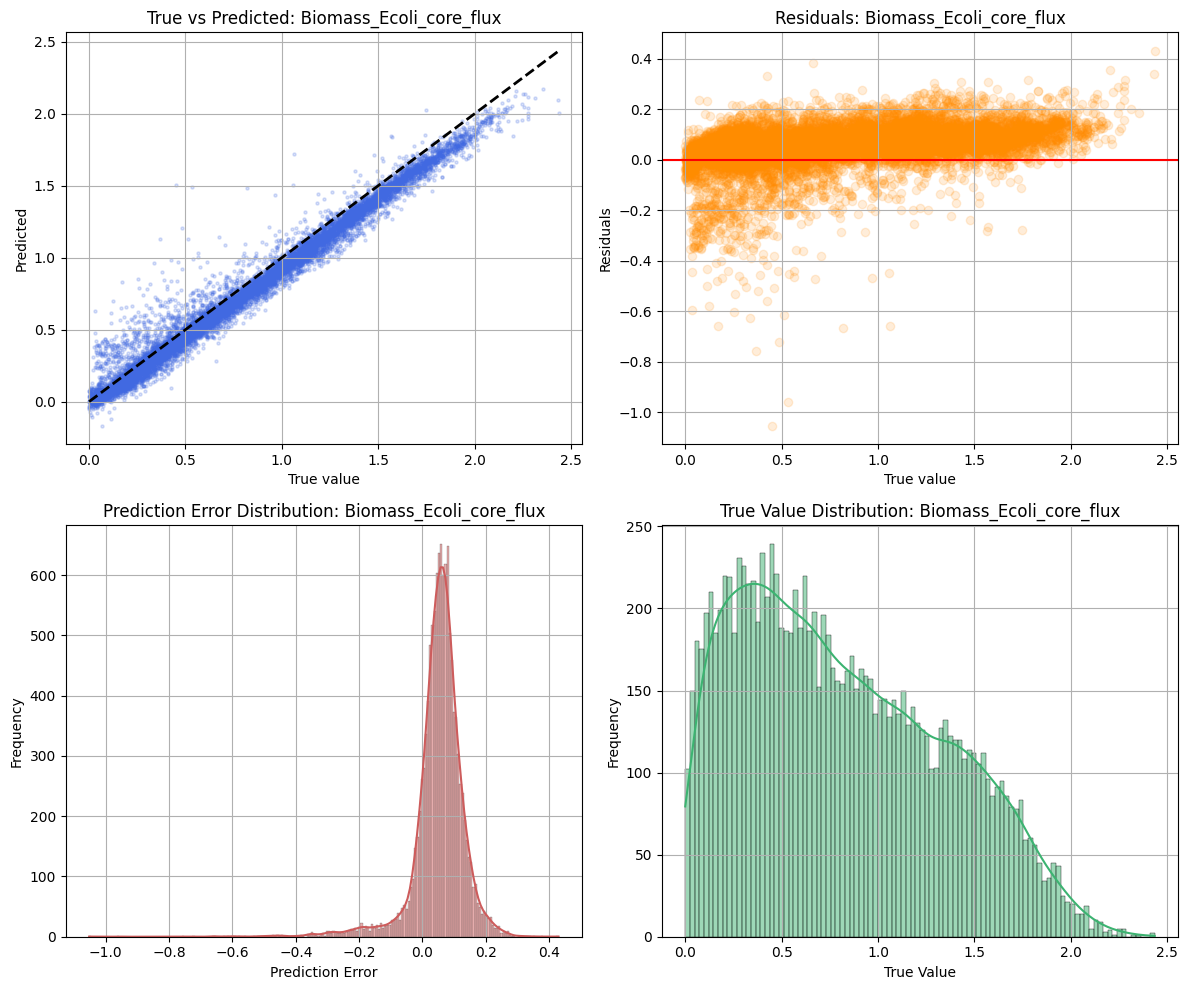

Number of parameters:
281222


In [33]:
train_losses_12842_256, test_losses_12842_256, model_12842_256 = train_model(d_model=128, n_heads=4, n_layers=2, d_ff=256)

plot_loss_curves(train_losses_12842_256, test_losses_12842_256, d_model=128)

plot_prediction_sample(X_test, y_test, model_12842_256)

plot_flux(model_12842_256, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_12842_256.parameters() if p.requires_grad ))

Epoch 100/1000 | Train Loss: 0.336037 | Test Loss: 0.387024
Epoch 200/1000 | Train Loss: 0.277309 | Test Loss: 0.278267
Epoch 300/1000 | Train Loss: 0.248786 | Test Loss: 0.324948
Epoch 400/1000 | Train Loss: 0.236219 | Test Loss: 0.238401
Epoch 500/1000 | Train Loss: 0.222375 | Test Loss: 0.236517
Epoch 600/1000 | Train Loss: 0.213992 | Test Loss: 0.228649
Epoch 700/1000 | Train Loss: 0.208616 | Test Loss: 0.260311
Epoch 800/1000 | Train Loss: 0.200897 | Test Loss: 0.207600
Epoch 900/1000 | Train Loss: 0.201177 | Test Loss: 0.205609
Epoch 1000/1000 | Train Loss: 0.213460 | Test Loss: 0.221567
Training Completed.
Training took 125 min 24.2 sec.


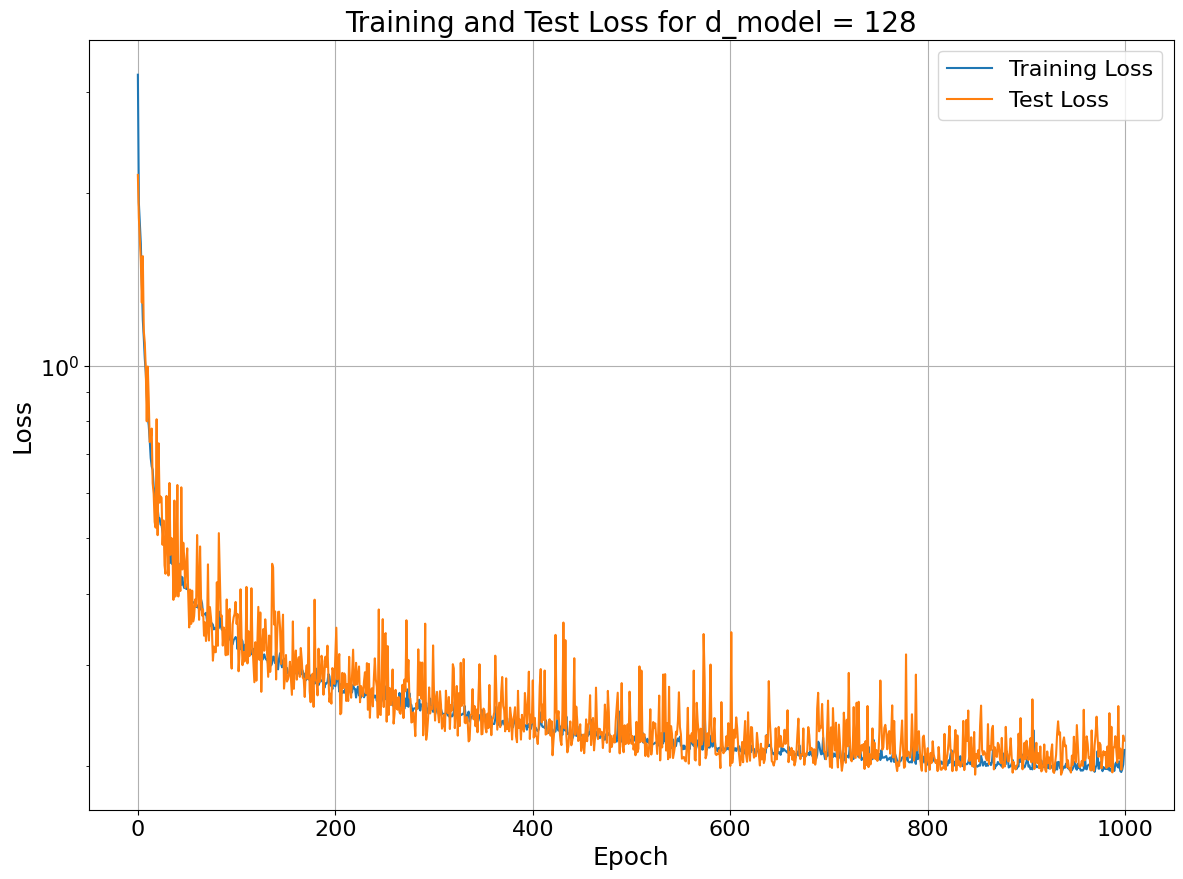

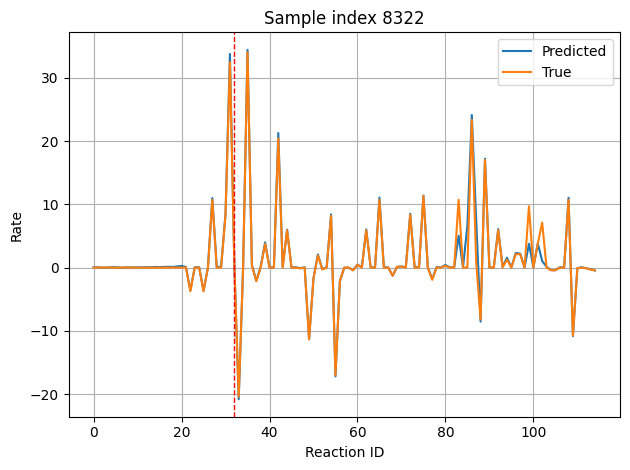

y_pred_tensor.shape: torch.Size([11779, 115, 1])
y_pred_full.shape: (11779, 115) min/max: -80.23296 109.447655
y_true_full.shape: (11779, 115) min/max: -78.54402 109.179535
y_pred_outputs.shape: (11779, 95) min/max: -80.23296 109.447655
y_true_outputs.shape: (11779, 95) min/max: -78.54402 109.179535
Flux column index in outputs: 12
y_true_outputs[:, idx] range: 4.0233743e-05 to 2.435643
y_pred_outputs[:, _idx] range: -0.016055107 to 2.3919263


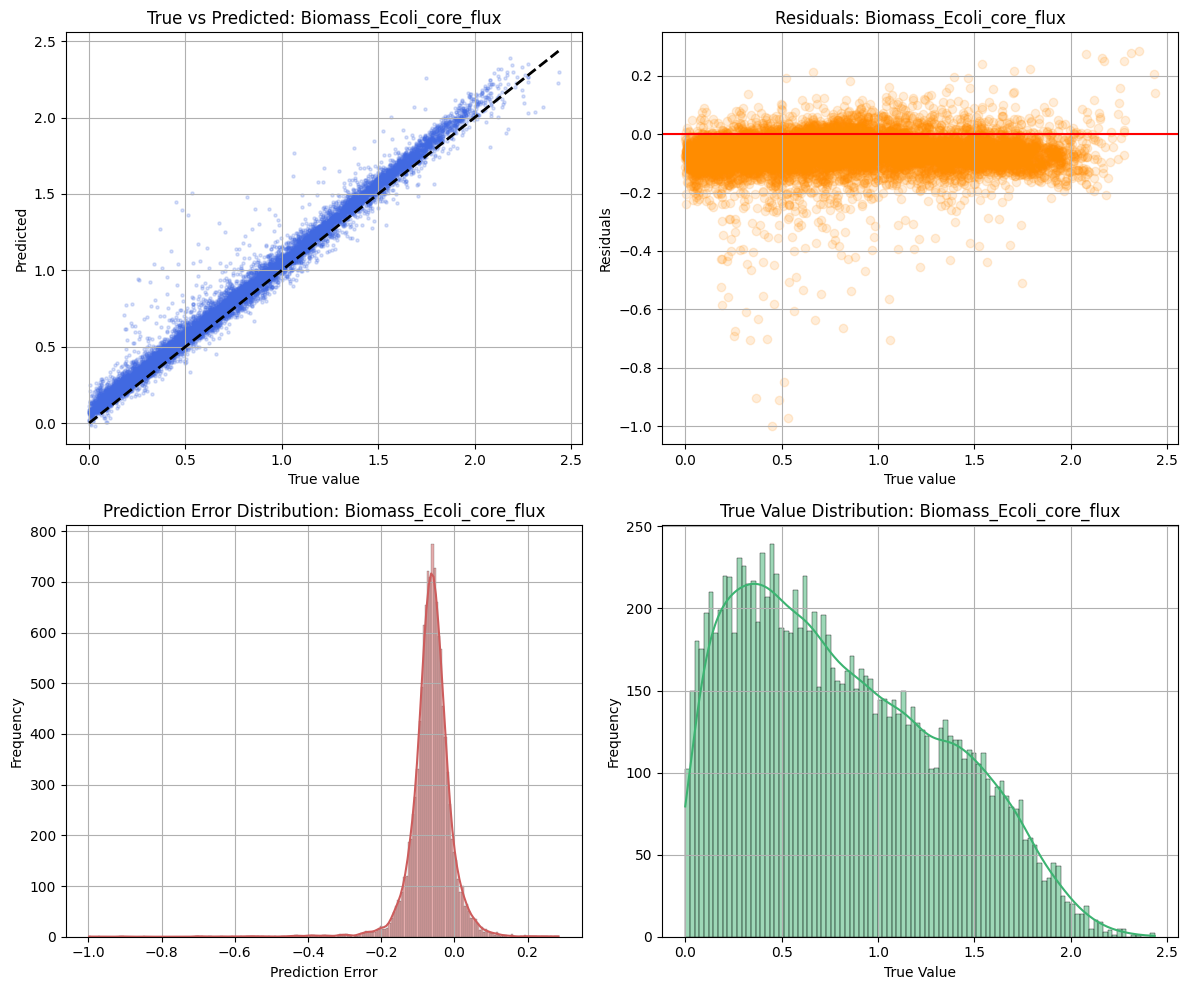

Number of parameters:
413830


In [34]:
train_losses_12842_512, test_losses_12842_512, model_12842_512 = train_model(d_model=128, n_heads=4, n_layers=2, d_ff=512)

plot_loss_curves(train_losses_12842_512, test_losses_12842_512, d_model=128)

plot_prediction_sample(X_test, y_test, model_12842_512)

plot_flux(model_12842_512, X_test, y_test, columns, 'Biomass_Ecoli_core_flux', device)

print('Number of parameters:')
print(sum( p.numel() for p in model_12842_512.parameters() if p.requires_grad ))